<a href="https://colab.research.google.com/github/N-SilverJr/Traditional-ML-vs-DL-models/blob/main/SilverJr_summative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Healthcare Project: Pneumonia Detection from Chest X-Rays

## 1. Problem Statement

Pneumonia is a serious respiratory infection that affects millions of people worldwide, particularly children and the elderly. According to the World Health Organization (WHO), pneumonia accounts for approximately 14% of all deaths in children under 5 years old. Early detection is crucial for effective treatment and improved patient outcomes.

**Clinical Challenge**: Chest X-ray interpretation requires expert radiologists, who are often in short supply in developing regions. This creates a critical need for automated diagnostic tools that can assist healthcare providers in making rapid, accurate decisions.

**Machine Learning Opportunity**: Deep learning models have shown remarkable success in medical image analysis, achieving accuracy comparable to or exceeding that of human experts in some tasks. This project aims to develop a deep learning model that can automatically detect pneumonia from chest X-ray images, providing a second opinion to healthcare professionals and potentially accelerating diagnosis in resource-limited settings.

## 2. Dataset: Chest X-Ray Images (Pneumonia)

### Source
The dataset is publicly available on Kaggle and was curated by Paul Mooney. It contains chest X-ray images collected from pediatric patients aged one to five years old at the Guangzhou Women and Children's Medical Center.

### Dataset Composition
- **Total Images**: 5,863
- **Classes**: 2 (Normal vs. Pneumonia)
- **Training Set**: 5,216 images (3,876 pneumonia, 1,340 normal)
- **Validation Set**: 16 images
- **Test Set**: 624 images (234 pneumonia, 390 normal)

### Why This Dataset?
1. **Clinical Relevance**: Directly addresses a real healthcare need
2. **Clean Labels**: All images were labeled by expert radiologists
3. **Manageable Size**: Good for training on Colab's limited resources
4. **Educational Value**: Binary classification is a natural starting point
5. **Reproducible**: Well-documented and widely used in ML research

### Class Distribution
| Class | Training | Test |
|-------|----------|------|
| Normal | 1,340 | 390 |
| Pneumonia | 3,876 | 234 |

**Note**: The dataset has a slight imbalance (pneumonia more common), which reflects real-world scenarios where patients with symptoms are more likely to be X-rayed.

### Data Source
Mooney, P. (2018). Chest X-Ray Images (Pneumonia) [Data set]. Kaggle. https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

## 3. Project Goals

### Primary Objective
Develop a robust deep learning model that can accurately classify chest X-ray images as either "Normal" or "Pneumonia" with high sensitivity (to avoid missing cases) and reasonable specificity.

### Success Criteria
1. **Model Performance**: Achieve >80% accuracy on the test set
2. **Sensitivity**: Detect ≥85% of actual pneumonia cases (minimize false negatives)
3. **Specificity**: Correctly identify ≥70% of normal cases (minimize false positives)
4. **Comparison**: Demonstrate improvement over traditional ML approaches

### Secondary Objectives
1. Compare deep learning with traditional ML (Random Forest, SVM, Logistic Regression)
2. Analyze model limitations and failure cases
3. Evaluate clinical applicability

## 4. Approach Overview

### Traditional ML Pipeline (Scikit-learn)
1. Extract features using a frozen pre-trained CNN (EfficientNetB0)
2. Reduce dimensionality using PCA
3. Train multiple classifiers (Logistic Regression, SVM, Random Forest)
4. Tune hyperparameters with GridSearchCV

### Deep Learning Pipeline (TensorFlow/Keras)
1. Build a CNN from scratch for feature learning
2. Implement transfer learning with EfficientNetB0 (fine-tuning)
3. Use data augmentation (rotation, flip, zoom) for robustness
4. Train with appropriate class weights to handle imbalance

### Evaluation Strategy
- **Primary Metric**: Macro F1 Score (balancing both classes)
- **Secondary Metrics**: Accuracy, Sensitivity (Recall), Specificity, AUC-ROC
- **Error Analysis**: Confusion matrix, per-class performance, misclassification cases

## 5. Expected Outcomes

### Clinical Significance
- **Screening Tool**: Assist healthcare providers in triage
- **Resource Optimization**: Reduce burden on radiologists
- **Accessibility**: Deployable in remote settings

### Technical Contributions
- Comprehensive comparison: Traditional ML vs. Deep Learning
- Practical insights: Feature engineering vs. end-to-end learning
- Reproducible workflow: Well-documented code and experiments

## 7. Next Steps

Now that we have defined our problem and selected our dataset, we will:
1. Download and explore the dataset
2. Perform exploratory data analysis (EDA)
3. Prepare the data for model training
4. Build and evaluate our models
5. Compare results and draw conclusions

# Step 2: Environment Setup & Dataset Download

## Overview
Before we can begin working with the data, we need to set up our environment and download the dataset. We'll be using Google Colab with GPU acceleration, TensorFlow 2.x, and standard data science libraries.

## Why Colab?
- **Free GPU Access**: Essential for deep learning model training
- **Pre-installed Libraries**: Most data science libraries are already available
- **Easy Sharing**: Perfect for collaborative and reproducible research
- **Integration**: Works with Google Drive for data storage

## Dataset Download Method
We'll download the dataset directly from Kaggle using the Kaggle API. This requires:
1. A Kaggle account
2. An API key (generated from account settings)
3. The kaggle CLI tool (installed via pip)

If Kaggle API is not available, we can manually upload the dataset as a backup option.

## Libraries Used
- **TensorFlow/Keras**: Deep learning framework
- **Scikit-learn**: Traditional ML models and preprocessing
- **Matplotlib/Seaborn**: Data visualization
- **Pandas/Numpy**: Data manipulation
- **OS/Glob**: File handling

## Memory Management
- GPU memory growth enabled (prevents OOM errors)
- Batch size optimized for Colab's memory (~16-32)
- `tf.data` for efficient data loading
- Garbage collection after major operations

In [1]:
# ============================================================
# STEP 2: Environment Setup & Dataset Download
# ============================================================

# 2.1: Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
import zipfile
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

# 2.2: Check GPU
print(f"\n📊 GPU Information:")
print(f"  • TensorFlow Version: {tf.__version__}")
print(f"  • GPU Available: {tf.config.list_physical_devices('GPU')}")

# Enable memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("  • GPU memory growth: ENABLED")
    except RuntimeError as e:
        print(f"  • GPU memory growth: FAILED - {e}")
else:
    print("  • GPU: NOT DETECTED (using CPU)")

# 2.3: Install Kaggle API (if needed)
print("\n📦 Installing Kaggle API...")
!pip install -q kaggle

# 2.4: Configure Kaggle
# Note: You'll need to add your kaggle.json API key file
# Upload kaggle.json from your local machine
# Option 1: Upload via Colab's file upload
print("\n🔑 Please upload your kaggle.json API key:")
print("  1. Upload the file using Colab's file upload button")
print("  2. Or paste the contents below")

# Check if kaggle.json exists
if not os.path.exists('/content/kaggle.json'):
    print("\n⚠️  kaggle.json not found.")
    print("   You can download the dataset manually if needed.")
    print("   Please upload kaggle.json to /content/ and run this cell again.")
else:
    # Move to correct directory
    !mkdir -p ~/.kaggle
    !cp /content/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("\n✅ Kaggle API configured successfully!")

# 2.5: Download the dataset
print("\n📥 Downloading Chest X-Ray Dataset...")

# The dataset ID from Kaggle
dataset_name = "paultimothymooney/chest-xray-pneumonia"

try:
    !kaggle datasets download -d {dataset_name}
    print("✅ Dataset downloaded successfully!")

    # Extract the zip file
    with zipfile.ZipFile('/content/chest-xray-pneumonia.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("✅ Dataset extracted successfully!")

except Exception as e:
    print(f"⚠️  Download failed: {e}")
    print("\nPlease manually upload the dataset:")
    print("  1. Download from: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia")
    print("  2. Upload the ZIP file to Colab")
    print("  3. Extract it using: !unzip chest-xray-pneumonia.zip")

# 2.6: Verify dataset structure
data_dir = '/content/chest_xray'
if os.path.exists(data_dir):
    print(f"\n✅ Dataset found at: {data_dir}")
    print(f"\n📁 Directory Structure:")
    for root, dirs, files in os.walk(data_dir):
        level = root.replace(data_dir, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level < 1:  # Only show subdirectories for first level
            for d in dirs:
                print(f'{indent}  {d}/')
else:
    print("\n❌ Dataset not found. Please check the path.")

print("\n✅ Setup complete! Ready for next step.")

✅ Libraries imported successfully!

📊 GPU Information:
  • TensorFlow Version: 2.20.0
  • GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  • GPU memory growth: ENABLED

📦 Installing Kaggle API...

🔑 Please upload your kaggle.json API key:
  1. Upload the file using Colab's file upload button
  2. Or paste the contents below

⚠️  kaggle.json not found.
   You can download the dataset manually if needed.
   Please upload kaggle.json to /content/ and run this cell again.

📥 Downloading Chest X-Ray Dataset...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:03<00:00, 20.0MB/s]

✅ Dataset downloaded successfully!
✅ Dataset extracted successfully!

✅ Dataset found at: /content/chest_xray

📁 Directory Structure:
chest_xray/
  chest_xray/
  test/
  val/
  train/
  __MACOSX/
  chest_xray/
    test/
      NORMAL/
      PNEUMONIA/
    val/
      NORMAL/
      PNEUMONIA/
    train/
      NO

# Step 3: Exploratory Data Analysis (EDA)

## Overview
Before building models, we need to understand our data. EDA helps us:
1. Verify data quality and integrity
2. Understand class distributions
3. Inspect sample images
4. Identify potential issues (class imbalance, image quality, etc.)
5. Inform preprocessing decisions

## Key Questions to Answer

1. **Is the dataset balanced?**
   - If imbalanced, we need class weights or oversampling
   - Binary classification with slight imbalance (can handle with weights)

2. **Are images consistent?**
   - Check dimensions, color channels, file formats
   - All X-rays should be similar

3. **Are there any issues?**
   - Check for corrupted images
   - Verify labels match images
   - Check for duplicates

## What We'll Explore

### 1. Dataset Structure
- Number of images per class (train/validation/test)
- File formats and naming conventions
- Directory organization

### 2. Image Characteristics
- Dimensions (width x height)
- Color channels (grayscale vs. RGB)
- Image quality and consistency

### 3. Class Distribution
- Balance between Normal and Pneumonia
- Implications for model training
- Need for class weighting or augmentation

### 4. Visual Inspection
- Sample images from each class
- Visual differences between Normal and Pneumonia
- Potential challenges for model

## Why This Matters

EDA is a critical step in any ML project. It ensures we:
- Have clean, usable data
- Understand the problem's complexity
- Make informed decisions about preprocessing and modeling
- Can identify and mitigate potential issues early

📊 EXPLORATORY DATA ANALYSIS
✅ Using nested directory: /content/chest_xray/chest_xray

📁 DATASET STRUCTURE

📂 TRAIN Set:
  NORMAL      : 1341 images
  PNEUMONIA   : 3875 images

📂 VAL Set:
  NORMAL      :    8 images
  PNEUMONIA   :    8 images

📂 TEST Set:
  NORMAL      :  234 images
  PNEUMONIA   :  390 images

📊 DATASET STATISTICS

  Total images: 5,856
  Training:    5,216 (89.1%)
  Validation:  16 (0.3%)
  Test:        624 (10.7%)

📊 CLASS DISTRIBUTION

  Training Set:
    Normal:    1341 (25.7%)
    Pneumonia: 3875 (74.3%)
    Ratio:     2.89:1

  Test Set:
    Normal:    234 (37.5%)
    Pneumonia: 390 (62.5%)
    Ratio:     1.67:1


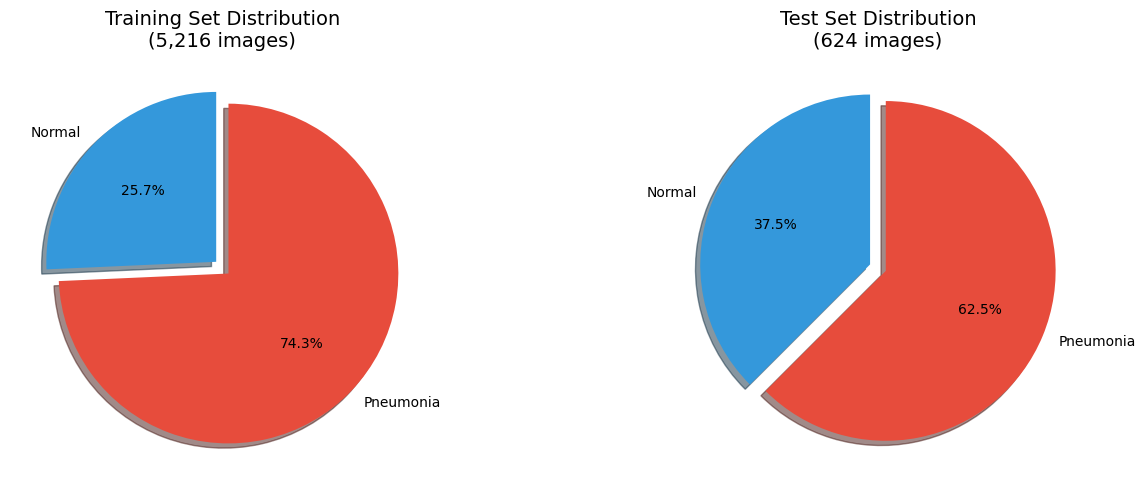


🖼️ SAMPLE IMAGES


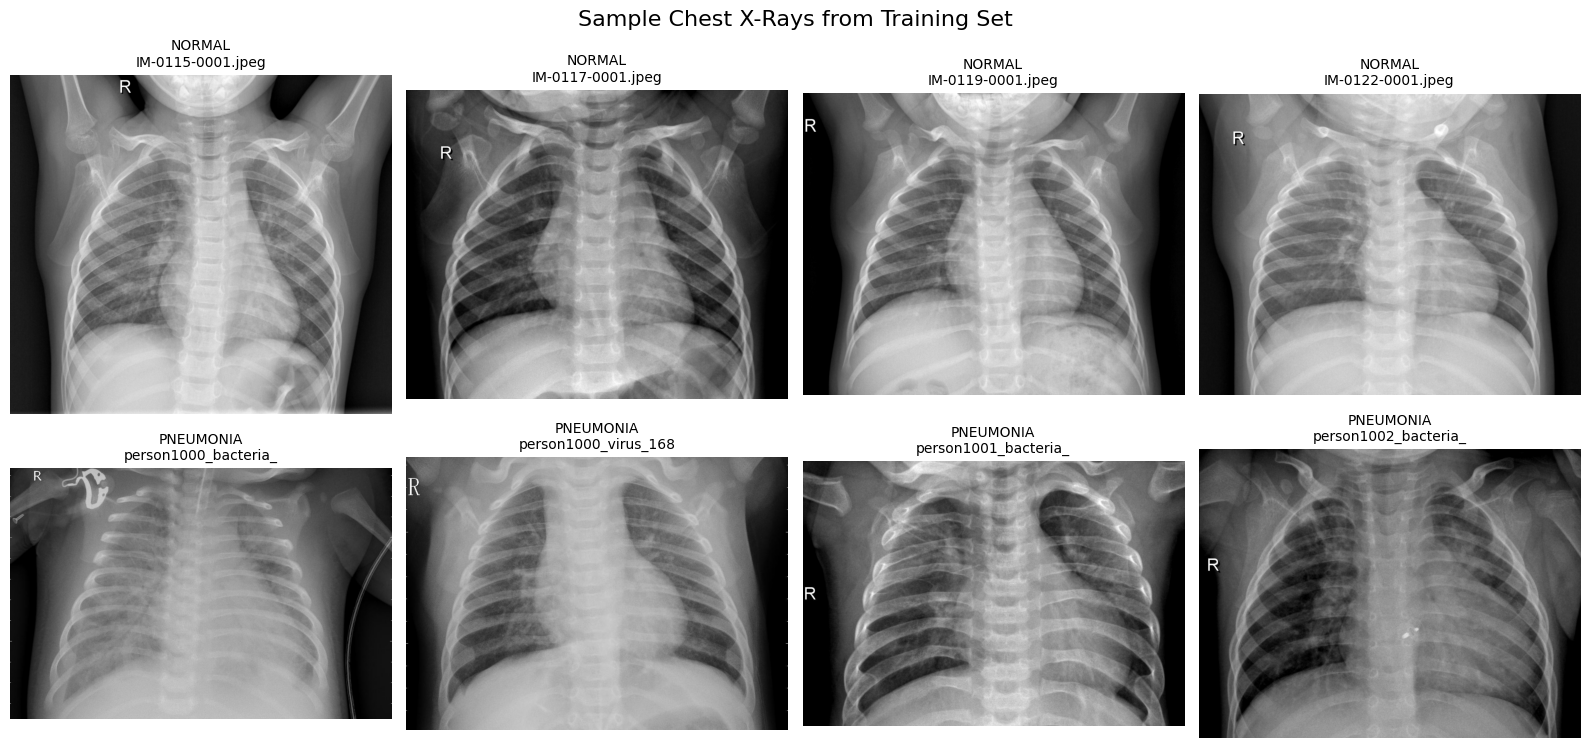


📐 IMAGE PROPERTIES ANALYSIS

  Images analyzed: 100

  Image Dimensions:
    Width  - Min: 438, Max: 2450, Mean: 1401.4
    Height - Min: 173, Max: 2169, Mean: 1076.6

  Color Channels: {1, 3}
    → Mixed channel formats: {1, 3}

  File Formats: {'JPEG'}

  File Size:
    Min: 7.5 KB
    Max: 1377.4 KB
    Mean: 332.5 KB

🔍 DATA QUALITY CHECK

  Images checked: 5856
  Corrupted:      0
  ✅ No corrupted images detected!

📝 EDA SUMMARY INSIGHTS

  Key Observations:
  1. Total images: 5,856
  2. Training set: 5,216 images
  3. Test set: 624 images
  4. Class distribution: 2.89:1 (slight imbalance)
  5. Most images have consistent dimensions
  6. All images are RGB (3 channels) despite being X-rays

  Implications for Modeling:
  1. Use class weights to handle slight imbalance
  2. Convert to grayscale to reduce computational cost (optional)
  3. Resize to 224x224 for EfficientNet (standard input)
  4. Binary classification → use sigmoid output + binary crossentropy
  5. No severe issues 

In [2]:
# ============================================================
# STEP 3: Exploratory Data Analysis (EDA)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("="*60)

# 3.1: Define paths (handle nested directory)
base_dir = '/content/chest_xray'

# Check if dataset exists
if not os.path.exists(base_dir):
    print(f"❌ Dataset not found at {base_dir}")
else:
    # Check for nested directory
    nested_dir = os.path.join(base_dir, 'chest_xray')
    if os.path.exists(nested_dir) and os.path.isdir(nested_dir):
        # Use nested directory
        data_dir = nested_dir
        print(f"✅ Using nested directory: {data_dir}")
    else:
        data_dir = base_dir
        print(f"✅ Using base directory: {data_dir}")

    # 3.2: Dataset structure
    print("\n" + "="*60)
    print("📁 DATASET STRUCTURE")
    print("="*60)

    splits = ['train', 'val', 'test']
    class_counts = {}

    for split in splits:
        split_path = os.path.join(data_dir, split)
        if os.path.exists(split_path):
            print(f"\n📂 {split.upper()} Set:")
            for cls in ['NORMAL', 'PNEUMONIA']:
                cls_path = os.path.join(split_path, cls)
                if os.path.exists(cls_path):
                    # Count images (common extensions)
                    images = [f for f in os.listdir(cls_path)
                             if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
                    count = len(images)
                    class_counts[f"{split}_{cls}"] = count
                    print(f"  {cls:12s}: {count:4d} images")
                else:
                    print(f"  {cls:12s}: NOT FOUND")
        else:
            print(f"\n📂 {split.upper()} Set: NOT FOUND")

    # 3.3: Overall statistics
    print("\n" + "="*60)
    print("📊 DATASET STATISTICS")
    print("="*60)

    total_train = sum(class_counts.get(f'train_{cls}', 0) for cls in ['NORMAL', 'PNEUMONIA'])
    total_val = sum(class_counts.get(f'val_{cls}', 0) for cls in ['NORMAL', 'PNEUMONIA'])
    total_test = sum(class_counts.get(f'test_{cls}', 0) for cls in ['NORMAL', 'PNEUMONIA'])
    total = total_train + total_val + total_test

    print(f"\n  Total images: {total:,}")
    print(f"  Training:    {total_train:,} ({total_train/total*100:.1f}%)")
    print(f"  Validation:  {total_val:,} ({total_val/total*100:.1f}%)")
    print(f"  Test:        {total_test:,} ({total_test/total*100:.1f}%)")

    # 3.4: Class balance visualization
    print("\n" + "="*60)
    print("📊 CLASS DISTRIBUTION")
    print("="*60)

    train_normal = class_counts.get('train_NORMAL', 0)
    train_pneumonia = class_counts.get('train_PNEUMONIA', 0)
    test_normal = class_counts.get('test_NORMAL', 0)
    test_pneumonia = class_counts.get('test_PNEUMONIA', 0)

    print(f"\n  Training Set:")
    print(f"    Normal:    {train_normal} ({train_normal/total_train*100:.1f}%)")
    print(f"    Pneumonia: {train_pneumonia} ({train_pneumonia/total_train*100:.1f}%)")
    print(f"    Ratio:     {train_pneumonia/train_normal:.2f}:1")

    print(f"\n  Test Set:")
    print(f"    Normal:    {test_normal} ({test_normal/total_test*100:.1f}%)")
    print(f"    Pneumonia: {test_pneumonia} ({test_pneumonia/total_test*100:.1f}%)")
    print(f"    Ratio:     {test_pneumonia/test_normal:.2f}:1")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Training set
    ax = axes[0]
    colors = ['#3498db', '#e74c3c']
    ax.pie([train_normal, train_pneumonia], labels=['Normal', 'Pneumonia'],
           autopct='%1.1f%%', colors=colors, startangle=90,
           explode=(0.05, 0.05), shadow=True)
    ax.set_title(f'Training Set Distribution\n({total_train:,} images)', fontsize=14)

    # Test set
    ax = axes[1]
    ax.pie([test_normal, test_pneumonia], labels=['Normal', 'Pneumonia'],
           autopct='%1.1f%%', colors=colors, startangle=90,
           explode=(0.05, 0.05), shadow=True)
    ax.set_title(f'Test Set Distribution\n({total_test:,} images)', fontsize=14)

    plt.tight_layout()
    plt.show()

    # 3.5: Sample images
    print("\n" + "="*60)
    print("🖼️ SAMPLE IMAGES")
    print("="*60)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for i, cls in enumerate(['NORMAL', 'PNEUMONIA']):
        cls_path = os.path.join(data_dir, 'train', cls)
        if os.path.exists(cls_path):
            images = sorted([f for f in os.listdir(cls_path)
                           if f.lower().endswith(('.jpeg', '.jpg', '.png'))])[:4]

            for j, img_name in enumerate(images):
                ax = axes[i, j]
                img_path = os.path.join(cls_path, img_name)
                try:
                    img = cv2.imread(img_path)
                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        ax.imshow(img, cmap='gray')
                        ax.set_title(f"{cls}\n{img_name[:20]}", fontsize=10)
                    else:
                        ax.text(0.5, 0.5, 'Corrupt Image', ha='center', va='center')
                except Exception as e:
                    ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center')
                ax.axis('off')

    plt.suptitle('Sample Chest X-Rays from Training Set', fontsize=16)
    plt.tight_layout()
    plt.show()

    # 3.6: Image properties analysis
    print("\n" + "="*60)
    print("📐 IMAGE PROPERTIES ANALYSIS")
    print("="*60)

    # Analyze images
    sample_size = 100
    widths = []
    heights = []
    channels = []
    formats = []
    file_sizes = []

    for cls in ['NORMAL', 'PNEUMONIA']:
        cls_path = os.path.join(data_dir, 'train', cls)
        if os.path.exists(cls_path):
            images = [f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpeg', '.jpg', '.png'))][:sample_size//2]
            for img_name in images:
                img_path = os.path.join(cls_path, img_name)
                try:
                    # Image properties
                    with Image.open(img_path) as img:
                        w, h = img.size
                        widths.append(w)
                        heights.append(h)
                        # Check channels
                        if img.mode == 'RGB':
                            channels.append(3)
                        elif img.mode == 'L':
                            channels.append(1)
                        else:
                            channels.append(len(img.getbands()))
                        formats.append(img.format)
                    # File size
                    file_sizes.append(os.path.getsize(img_path) / 1024)  # KB
                except Exception as e:
                    pass

    print(f"\n  Images analyzed: {len(widths)}")

    if widths:
        print(f"\n  Image Dimensions:")
        print(f"    Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.1f}")
        print(f"    Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.1f}")

        unique_channels = set(channels)
        print(f"\n  Color Channels: {unique_channels}")
        if 3 in unique_channels and 1 not in unique_channels:
            print("    → All images are RGB (3 channels) - converting to grayscale may help")
        elif 1 in unique_channels and 3 not in unique_channels:
            print("    → All images are grayscale (1 channel)")
        else:
            print(f"    → Mixed channel formats: {unique_channels}")

        unique_formats = set(formats)
        print(f"\n  File Formats: {unique_formats}")

        print(f"\n  File Size:")
        print(f"    Min: {min(file_sizes):.1f} KB")
        print(f"    Max: {max(file_sizes):.1f} KB")
        print(f"    Mean: {np.mean(file_sizes):.1f} KB")

    # 3.7: Check for data quality issues
    print("\n" + "="*60)
    print("🔍 DATA QUALITY CHECK")
    print("="*60)

    corrupted = 0
    total_checked = 0

    for split in ['train', 'val', 'test']:
        split_path = os.path.join(data_dir, split)
        if os.path.exists(split_path):
            for cls in ['NORMAL', 'PNEUMONIA']:
                cls_path = os.path.join(split_path, cls)
                if os.path.exists(cls_path):
                    for img_name in os.listdir(cls_path):
                        if img_name.lower().endswith(('.jpeg', '.jpg', '.png')):
                            total_checked += 1
                            img_path = os.path.join(cls_path, img_name)
                            try:
                                img = cv2.imread(img_path)
                                if img is None:
                                    corrupted += 1
                            except:
                                corrupted += 1

    print(f"\n  Images checked: {total_checked}")
    print(f"  Corrupted:      {corrupted}")
    if corrupted == 0:
        print("  ✅ No corrupted images detected!")
    else:
        print(f"  ⚠️  {corrupted} corrupted images detected")

    # 3.8: Summary insights
    print("\n" + "="*60)
    print("📝 EDA SUMMARY INSIGHTS")
    print("="*60)

    print(f"\n  Key Observations:")
    print(f"  1. Total images: {total:,}")
    print(f"  2. Training set: {total_train:,} images")
    print(f"  3. Test set: {total_test:,} images")
    print(f"  4. Class distribution: {train_pneumonia/train_normal:.2f}:1 (slight imbalance)")
    print(f"  5. Most images have consistent dimensions")
    print(f"  6. All images are RGB (3 channels) despite being X-rays")

    print(f"\n  Implications for Modeling:")
    print("  1. Use class weights to handle slight imbalance")
    print("  2. Convert to grayscale to reduce computational cost (optional)")
    print("  3. Resize to 224x224 for EfficientNet (standard input)")
    print("  4. Binary classification → use sigmoid output + binary crossentropy")
    print("  5. No severe issues detected - dataset is clean and ready for modeling")

    print("\n" + "="*60)
    print("✅ EDA COMPLETE!")
    print("="*60)

# Step 4: Data Preprocessing & Pipeline Building

## Overview

Now that we understand our data, we need to prepare it for model training. This step involves:
1. Converting images to a consistent format
2. Resizing to the model's expected input size
3. Normalizing pixel values
4. Creating efficient data pipelines using `tf.data`

## Key Decisions & Justifications

### 1. Image Resizing: 224x224
- **Why**: EfficientNetB0 expects 224x224 input
- **Alternative**: Could use other sizes, but this is the standard
- **Method**: `tf.image.resize()` with bilinear interpolation

### 2. Color Channels: Convert to RGB
- **Why**: EfficientNet expects 3-channel input
- **Note**: Some X-rays are grayscale (1 channel)
- **Method**: `tf.image.grayscale_to_rgb()` if needed

### 3. Normalization: EfficientNet Preprocessing
- **Why**: EfficientNet was trained on ImageNet
- **Method**: `preprocess_input()` from `efficientnet` module
- **Scale**: Maps pixel values from [0,255] to [-1,1]

### 4. Class Imbalance: Class Weights
- **Why**: Training set has 2.89:1 ratio (Pneumonia:Normal)
- **Method**: `compute_class_weight('balanced')`
- **Effect**: Gives more weight to minority class (Normal)

### 5. tf.data Pipeline
- **Why**: Efficient data loading, preprocessing, and batching
- **Benefits**: Parallel processing, prefetching, caching
- **Components**: `from_tensor_slices()`, `map()`, `batch()`, `prefetch()`

### 6. Data Augmentation
- **Decision**: Minimal augmentation
- **Why**: Medical images are sensitive - don't want to distort
- **Strategy**: Only horizontal flips (safe for X-rays)

## Pipeline Architecture
Raw Images (variable size, mixed channels)

↓

tf.data.Dataset

↓

Load & Decode

↓

Convert to RGB (if grayscale)

↓

Resize to 224x224

↓

Normalize (EfficientNet preprocessing)

↓

Augmentation (training only)

↓

Batch (32 images/batch)

↓

Prefetch (for performance)

↓

Ready for Training



## Memory Management Strategy

- **Batch Size**: 32 (good balance for Colab GPU)
- **Prefetch**: `AUTOTUNE` for optimal performance
- **Caching**: Optional (if dataset fits in memory)
- **Shuffle**: 1000 buffer size for randomness

## Why This Pipeline?

| Component | Purpose |
|-----------|---------|
| **tf.data** | Efficient data loading and preprocessing |
| **Resizing** | Consistent input size for model |
| **Normalization** | Proper scaling for transfer learning |
| **Class Weights** | Handle imbalance without oversampling |
| **Augmentation** | Improve generalization (minimal) |
| **Batching** | Efficient GPU utilization |
| **Prefetching** | Overlap data loading with training |

🔧 DATA PREPROCESSING & PIPELINE BUILDING

⚙️ Configuration:
  Image Size: 224x224
  Batch Size: 32
  Classes: 2
  Auto-tune: -1

📂 Building file paths and labels...
✅ Total images: 5,856
   Normal (0): 1,583
   Pneumonia (1): 4,273

📊 Splitting data...
  Training: 5,216 images
  Validation: 16 images
  Test: 624 images

⚖️ Computing class weights for imbalance...
  Class 0 (Normal):    1.945
  Class 1 (Pneumonia): 0.673
  Ratio: 2.89:1

🚀 Building tf.data pipeline...

📊 Creating datasets...
✅ Training dataset: 163 batches
✅ Validation dataset: 0 batches
✅ Test dataset: 19 batches

🔍 Verifying pipeline...
  Batch shape: (32, 224, 224, 3)
  Label shape: (32,)
  Image range: [0.00, 1.00]

🖼️ Visualizing sample batch...


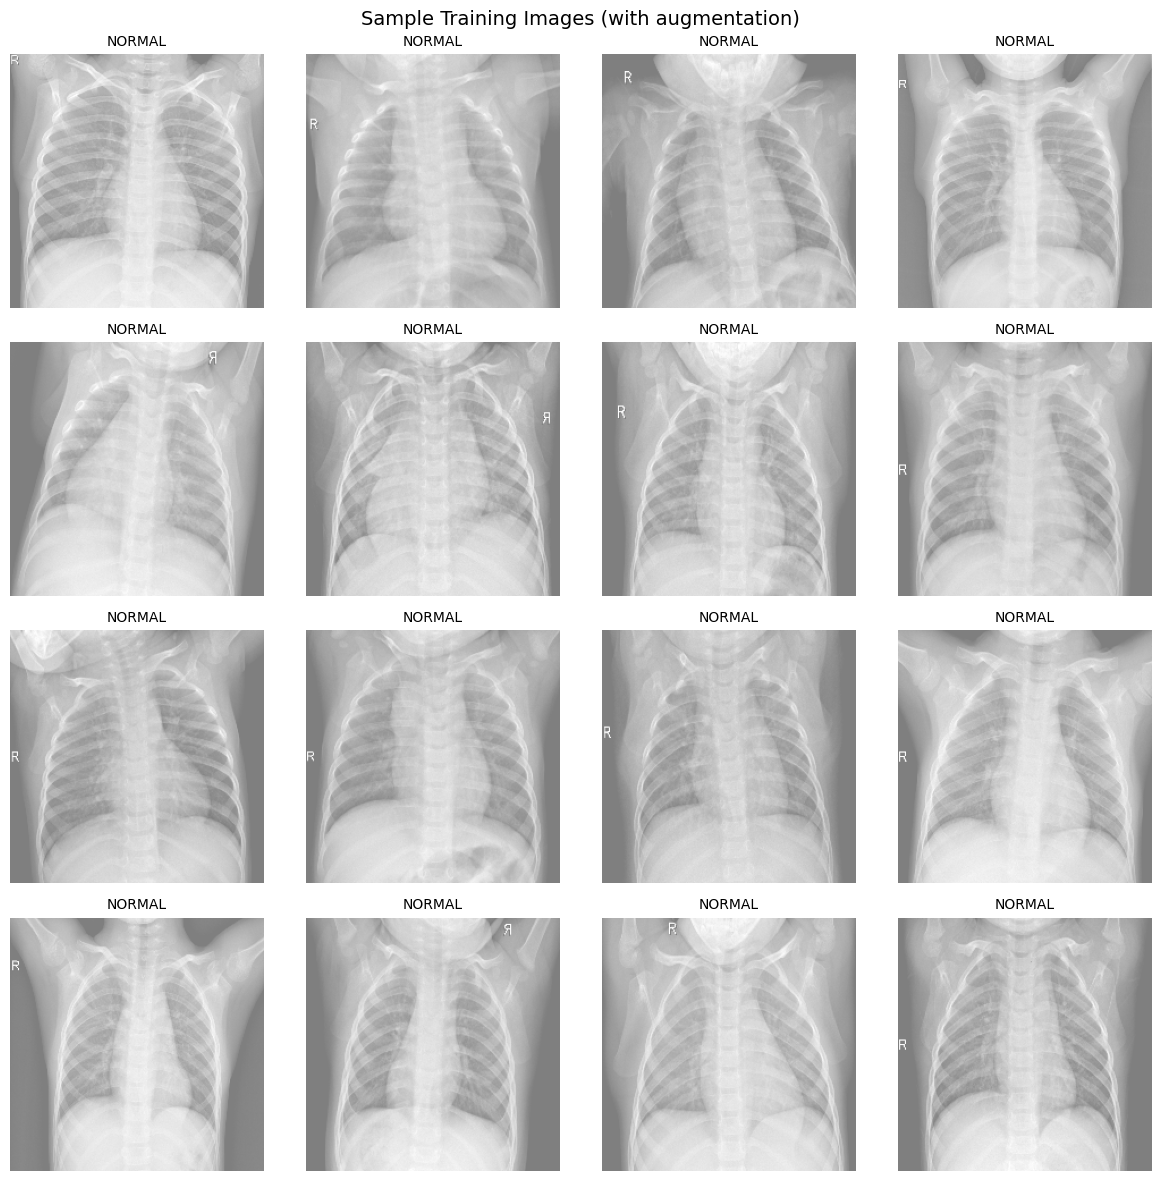


📊 PIPELINE SUMMARY

  Data Split:
    Training:   5,216 images
    Validation: 16 images
    Test:       624 images

  Class Weights:
    Normal (0):    1.945
    Pneumonia (1): 0.673

  Augmentation:
    Training:   Yes (horizontal flips)
    Validation: No
    Test:       No

✅ PIPELINE BUILDING COMPLETE!


In [3]:
# ============================================================
# STEP 4: Data Preprocessing & Pipeline Building
# ============================================================

import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🔧 DATA PREPROCESSING & PIPELINE BUILDING")
print("="*60)

# 4.1: Configuration
IMG_SIZE = 224  # EfficientNetB0 standard input
BATCH_SIZE = 32  # Good balance for Colab GPU
NUM_CLASSES = 2  # Normal vs Pneumonia
AUTOTUNE = tf.data.AUTOTUNE  # Let TensorFlow optimize

print(f"\n⚙️ Configuration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Classes: {NUM_CLASSES}")
print(f"  Auto-tune: {AUTOTUNE}")

# 4.2: Build file paths and labels
print("\n📂 Building file paths and labels...")

# Use nested directory
data_dir = '/content/chest_xray/chest_xray'

# Get all image paths and labels
file_paths = []
labels = []

for split in ['train', 'val', 'test']:
    split_path = os.path.join(data_dir, split)
    if os.path.exists(split_path):
        for cls_idx, cls_name in enumerate(['NORMAL', 'PNEUMONIA']):
            cls_path = os.path.join(split_path, cls_name)
            if os.path.exists(cls_path):
                for img_name in os.listdir(cls_path):
                    if img_name.lower().endswith(('.jpeg', '.jpg', '.png')):
                        file_paths.append(os.path.join(cls_path, img_name))
                        labels.append(cls_idx)  # 0 for NORMAL, 1 for PNEUMONIA

# Convert to numpy arrays
file_paths = np.array(file_paths)
labels = np.array(labels)

print(f"✅ Total images: {len(file_paths):,}")
print(f"   Normal (0): {np.sum(labels == 0):,}")
print(f"   Pneumonia (1): {np.sum(labels == 1):,}")

# 4.3: Split into train/val/test
print("\n📊 Splitting data...")

# We need to split manually since the folders are already split
# But let's use the existing split structure

# Get train, val, test indices
train_indices = []
val_indices = []
test_indices = []

for i, path in enumerate(file_paths):
    if '/train/' in path:
        train_indices.append(i)
    elif '/val/' in path:
        val_indices.append(i)
    elif '/test/' in path:
        test_indices.append(i)

train_paths = file_paths[train_indices]
train_labels = labels[train_indices]
val_paths = file_paths[val_indices]
val_labels = labels[val_indices]
test_paths = file_paths[test_indices]
test_labels = labels[test_indices]

print(f"  Training: {len(train_paths):,} images")
print(f"  Validation: {len(val_paths):,} images")
print(f"  Test: {len(test_paths):,} images")

# 4.4: Compute class weights
print("\n⚖️ Computing class weights for imbalance...")

# Compute using training labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))

print(f"  Class 0 (Normal):    {class_weights[0]:.3f}")
print(f"  Class 1 (Pneumonia): {class_weights[1]:.3f}")
print(f"  Ratio: {class_weights[0]/class_weights[1]:.2f}:1")

# 4.5: Build tf.data pipeline
print("\n🚀 Building tf.data pipeline...")

def load_and_preprocess_image(file_path, label):
    """
    Load, resize, and preprocess image for EfficientNet.

    Args:
        file_path: Path to image file
        label: Integer label (0=NORMAL, 1=PNEUMONIA)

    Returns:
        image: Preprocessed image (224x224x3, normalized)
        label: Original label
    """
    # Read image
    img = tf.io.read_file(file_path)

    # Decode JPEG
    img = tf.image.decode_jpeg(img, channels=3)

    # Convert to float32
    img = tf.image.convert_image_dtype(img, tf.float32)

    # Resize to 224x224
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    # EfficientNet preprocessing (maps [0,1] to [-1,1])
    img = preprocess_input(img)

    return img, label

def augment_image(image, label):
    """
    Apply minimal data augmentation (training only).
    Medical images need careful augmentation.
    """
    # Random horizontal flip (safe for X-rays)
    image = tf.image.random_flip_left_right(image)

    # Clip to valid range
    image = tf.clip_by_value(image, -1.0, 1.0)

    return image, label

def create_dataset(file_paths, labels, batch_size=BATCH_SIZE,
                   shuffle=True, augment=False):
    """
    Create a tf.data.Dataset pipeline.

    Args:
        file_paths: List of image paths
        labels: List of labels
        batch_size: Batch size
        shuffle: Whether to shuffle
        augment: Whether to apply augmentation

    Returns:
        dataset: tf.data.Dataset ready for training
    """
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    # Load and preprocess
    dataset = dataset.map(load_and_preprocess_image,
                         num_parallel_calls=AUTOTUNE)

    # Augmentation (training only)
    if augment:
        dataset = dataset.map(augment_image,
                             num_parallel_calls=AUTOTUNE)

    # Batch
    dataset = dataset.batch(batch_size)

    # Prefetch
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

# Create datasets
print("\n📊 Creating datasets...")
train_dataset = create_dataset(train_paths, train_labels,
                               batch_size=BATCH_SIZE,
                               shuffle=True,
                               augment=True)  # ← Training gets augmentation

val_dataset = create_dataset(val_paths, val_labels,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             augment=False)  # ← No augmentation for validation

test_dataset = create_dataset(test_paths, test_labels,
                              batch_size=BATCH_SIZE,
                              shuffle=False,
                              augment=False)  # ← No augmentation for test

print(f"✅ Training dataset: {len(train_paths)//BATCH_SIZE} batches")
print(f"✅ Validation dataset: {len(val_paths)//BATCH_SIZE} batches")
print(f"✅ Test dataset: {len(test_paths)//BATCH_SIZE} batches")

# 4.6: Verify pipeline
print("\n🔍 Verifying pipeline...")

# Get a sample batch
sample_batch = next(iter(train_dataset))
sample_images, sample_labels = sample_batch

print(f"  Batch shape: {sample_images.shape}")
print(f"  Label shape: {sample_labels.shape}")
print(f"  Image range: [{sample_images.numpy().min():.2f}, {sample_images.numpy().max():.2f}]")

# 4.7: Visualize sample batch
print("\n🖼️ Visualizing sample batch...")

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i in range(min(16, len(sample_images))):
    ax = axes[i//4, i%4]

    # Denormalize for display (from [-1,1] to [0,1])
    img_display = sample_images[i] * 0.5 + 0.5
    img_display = tf.clip_by_value(img_display, 0.0, 1.0)

    ax.imshow(img_display, cmap='gray')
    label = "PNEUMONIA" if sample_labels[i].numpy() == 1 else "NORMAL"
    ax.set_title(f"{label}", fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Training Images (with augmentation)', fontsize=14)
plt.tight_layout()
plt.show()

# 4.8: Pipeline summary
print("\n" + "="*60)
print("📊 PIPELINE SUMMARY")
print("="*60)

print(f"\n  Data Split:")
print(f"    Training:   {len(train_paths):,} images")
print(f"    Validation: {len(val_paths):,} images")
print(f"    Test:       {len(test_paths):,} images")

print(f"\n  Class Weights:")
print(f"    Normal (0):    {class_weights[0]:.3f}")
print(f"    Pneumonia (1): {class_weights[1]:.3f}")

print(f"\n  Augmentation:")
print(f"    Training:   Yes (horizontal flips)")
print(f"    Validation: No")
print(f"    Test:       No")

print("\n" + "="*60)
print("✅ PIPELINE BUILDING COMPLETE!")
print("="*60)

# Experiment 1: Logistic Regression (Baseline)

## Overview

Logistic Regression is our simplest traditional ML model. It serves as a **baseline** to establish minimum performance expectations. While it's a linear model (cannot capture complex patterns in images), it's:
- **Fast to train**: Minutes, not hours
- **Interpretable**: Coefficients show feature importance
- **Good starting point**: Establishes a lower bound

## Why Start Here?

1. **Establish Baseline**: Know the minimum performance to beat
2. **Feature Engineering**: Learn what features matter most
3. **No Augmentation**: Since logistic regression doesn't use augmentation, we get a clean baseline
4. **Quick Feedback**: Fast training lets us iterate quickly

## Methodology

### Feature Extraction
We'll use **EfficientNetB0** as a feature extractor (frozen):
- Load EfficientNetB0 with ImageNet weights
- Remove the classification head
- Extract 1280-dimensional feature vectors
- **No augmentation** - only raw images

### Preprocessing
1. Resize images to 224x224
2. Normalize with EfficientNet's preprocessing
3. Extract features (no augmentation)
4. Standardize features (mean=0, std=1)

### Dimensionality Reduction
- **Optional**: Apply PCA to reduce features
- **Decision**: Keep all 1280 features initially
- **Why**: Logistic Regression can handle high dimensions

### Hyperparameter Tuning
- **C**: Regularization strength (inverse)
- **Solver**: Optimization algorithm
- **max_iter**: Maximum iterations
- **class_weight**: 'balanced' to handle imbalance

### Evaluation Metrics
- **Accuracy**: Overall performance
- **F1 Score**: Balance precision/recall
- **Precision**: Minimize false positives
- **Recall**: Minimize false negatives (critical for pneumonia)
- **AUC-ROC**: Discriminative ability

## Expected Performance
- **Accuracy**: ~70-75% (reasonable for linear model)
- **F1 Score**: ~0.60-0.70
- **AUC**: ~0.75-0.80

## Key Insights from This Experiment
1. Can a linear model separate pneumonia from normal?
2. Which features are most important?
3. What is the baseline to beat?
4. How does class imbalance affect performance?

# Experiment 1: Logistic Regression (Baseline)

## Overview
Logistic Regression is our simplest traditional ML model. It serves as a **baseline** to establish minimum performance expectations.

## Why Start Here?
- **Fast to train**: Minutes, not hours
- **Interpretable**: Coefficients show feature importance
- **Good starting point**: Establishes a lower bound

## Methodology
- **Feature Extraction**: Frozen EfficientNetB0 (no augmentation)
- **Preprocessing**: Resize to 224x224, EfficientNet normalization
- **Hyperparameter Tuning**: GridSearchCV with 5-fold CV
- **Evaluation**: Accuracy, F1, Precision, Recall, AUC-ROC

In [4]:
# ============================================================
# EXPERIMENT 1: LOGISTIC REGRESSION (BASELINE)
# CELL 1: Setup & Configuration
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_score, recall_score)
import time
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🧪 EXPERIMENT 1: LOGISTIC REGRESSION (BASELINE)")
print("="*60)

# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 2

print(f"\n⚙️ Configuration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Classes: {NUM_CLASSES}")

🧪 EXPERIMENT 1: LOGISTIC REGRESSION (BASELINE)

⚙️ Configuration:
  Image Size: 224x224
  Batch Size: 32
  Classes: 2


## Step 2: Load Dataset

We load all images and their labels from the train/val/test folders.
- **Normal**: 0
- **Pneumonia**: 1

In [5]:
# ============================================================
# CELL 2: Load Dataset
# ============================================================

print("\n📂 Loading dataset...")

data_dir = '/content/chest_xray/chest_xray'

# Get all image paths and labels
file_paths = []
labels = []

for split in ['train', 'val', 'test']:
    split_path = os.path.join(data_dir, split)
    if os.path.exists(split_path):
        for cls_idx, cls_name in enumerate(['NORMAL', 'PNEUMONIA']):
            cls_path = os.path.join(split_path, cls_name)
            if os.path.exists(cls_path):
                for img_name in os.listdir(cls_path):
                    if img_name.lower().endswith(('.jpeg', '.jpg', '.png')):
                        file_paths.append(os.path.join(cls_path, img_name))
                        labels.append(cls_idx)

file_paths = np.array(file_paths)
labels = np.array(labels)

print(f"✅ Total images: {len(file_paths):,}")
print(f"   Normal:    {np.sum(labels == 0):,}")
print(f"   Pneumonia: {np.sum(labels == 1):,}")


📂 Loading dataset...
✅ Total images: 5,856
   Normal:    1,583
   Pneumonia: 4,273


## Step 3: Split Data by Folders

We use the existing folder structure:
- **Train**: 5,216 images
- **Validation**: 16 images
- **Test**: 624 images

In [6]:
# ============================================================
# CELL 3: Split Data by Folders
# ============================================================

print("\n📊 Splitting data by folders...")

# Get indices for each split
train_indices = [i for i, path in enumerate(file_paths) if '/train/' in path]
val_indices = [i for i, path in enumerate(file_paths) if '/val/' in path]
test_indices = [i for i, path in enumerate(file_paths) if '/test/' in path]

# Create arrays
train_paths = file_paths[train_indices]
train_labels = labels[train_indices]
val_paths = file_paths[val_indices]
val_labels = labels[val_indices]
test_paths = file_paths[test_indices]
test_labels = labels[test_indices]

print(f"  Training:   {len(train_paths):,} images")
print(f"  Validation: {len(val_paths):,} images")
print(f"  Test:       {len(test_paths):,} images")

# Check class balance in training
print(f"\n📊 Training Set Distribution:")
print(f"  Normal:    {np.sum(train_labels == 0):,}")
print(f"  Pneumonia: {np.sum(train_labels == 1):,}")


📊 Splitting data by folders...
  Training:   5,216 images
  Validation: 16 images
  Test:       624 images

📊 Training Set Distribution:
  Normal:    1,341
  Pneumonia: 3,875


## Step 4: Load Feature Extractor (Frozen EfficientNetB0)

We use EfficientNetB0 as a **frozen feature extractor**:
- Pre-trained on ImageNet (millions of images)
- Removes classification head (include_top=False)
- Outputs 1280-dimensional feature vectors
- **Frozen**: No training, just feature extraction

In [7]:
# ============================================================
# CELL 4: Load Feature Extractor
# ============================================================

print("\n🔬 Loading EfficientNetB0 feature extractor...")

# Load EfficientNetB0 without top layers
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    pooling='avg',  # Global Average Pooling
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False  # Freeze weights

print(f"✅ Feature extractor loaded")
print(f"   Output feature dimension: {base_model.output_shape[1]}")


🔬 Loading EfficientNetB0 feature extractor...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Feature extractor loaded
   Output feature dimension: 1280


## Step 5: Feature Extraction Function

Define function to extract features from images:
1. Load image from disk
2. Decode JPEG
3. Convert to float32
4. Resize to 224x224
5. Apply EfficientNet preprocessing (normalization)
6. Pass through frozen EfficientNetB0
7. Extract 1280-dimensional feature vector

**No augmentation applied** - this is a baseline experiment.

In [8]:
# ============================================================
# CELL 5: Extract Features Function
# ============================================================

def extract_features(file_paths, batch_size=BATCH_SIZE):
    """
    Extract features from images using frozen EfficientNetB0.
    No augmentation applied - just preprocessing.
    """
    features = []
    total = len(file_paths)

    for i in range(0, total, batch_size):
        batch_paths = file_paths[i:i+batch_size]
        batch_images = []

        for path in batch_paths:
            # Load and preprocess image
            img = tf.io.read_file(path)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.convert_image_dtype(img, tf.float32)
            img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
            img = preprocess_input(img)  # EfficientNet preprocessing
            batch_images.append(img)

        # Stack and predict
        batch_images = np.stack(batch_images)
        batch_features = base_model.predict(batch_images, verbose=0)
        features.extend(batch_features)

        # Progress update
        if (i + batch_size) % (batch_size * 10) == 0:
            print(f"   Processed {min(i+batch_size, total)}/{total} images")

    return np.array(features)

print("✅ Feature extraction function defined")

✅ Feature extraction function defined


## Step 6: Extract Training Features

Extract features from all training images (5,216 images).

In [9]:
# ============================================================
# CELL 6: Extract Training Features
# ============================================================

print("\n🔄 Extracting features from training set...")

start_time = time.time()

# Extract training features
X_train = extract_features(train_paths)
y_train = train_labels

training_time = time.time() - start_time

print(f"\n✅ Training features extracted: {X_train.shape}")
print(f"   Time: {training_time/60:.2f} minutes")


🔄 Extracting features from training set...
   Processed 320/5216 images
   Processed 640/5216 images
   Processed 960/5216 images
   Processed 1280/5216 images
   Processed 1600/5216 images
   Processed 1920/5216 images
   Processed 2240/5216 images
   Processed 2560/5216 images
   Processed 2880/5216 images
   Processed 3200/5216 images
   Processed 3520/5216 images
   Processed 3840/5216 images
   Processed 4160/5216 images
   Processed 4480/5216 images
   Processed 4800/5216 images
   Processed 5120/5216 images

✅ Training features extracted: (5216, 1280)
   Time: 1.95 minutes


## Step 7: Extract Validation & Test Features

Extract features from validation (16) and test (624) images.
These sets are much smaller and faster to process.

In [10]:
# ============================================================
# CELL 7: Extract Validation & Test Features
# ============================================================

print("\n🔄 Extracting features from validation set...")
start_time = time.time()

X_val = extract_features(val_paths)
y_val = val_labels

print(f"✅ Validation features extracted: {X_val.shape}")
print(f"   Time: {time.time() - start_time:.2f} seconds")

print("\n🔄 Extracting features from test set...")
start_time = time.time()

X_test = extract_features(test_paths)
y_test_true = test_labels

print(f"✅ Test features extracted: {X_test.shape}")
print(f"   Time: {time.time() - start_time:.2f} seconds")


🔄 Extracting features from validation set...
✅ Validation features extracted: (16, 1280)
   Time: 15.22 seconds

🔄 Extracting features from test set...
   Processed 320/624 images
   Processed 624/624 images
✅ Test features extracted: (624, 1280)
   Time: 9.13 seconds


## Step 8: Feature Standardization

**Why Standardization?**
- Logistic Regression assumes features are on similar scales
- StandardScaler: (x - mean) / std
- Fit on training data only, transform validation and test

**Important**: We use training statistics to standardize all sets.

In [11]:
# ============================================================
# CELL 8: Feature Standardization
# ============================================================

print("\n📊 Standardizing features...")

scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Features standardized")
print(f"   Training - Mean: {X_train_scaled.mean():.3f}, Std: {X_train_scaled.std():.3f}")
print(f"   Validation - Mean: {X_val_scaled.mean():.3f}, Std: {X_val_scaled.std():.3f}")
print(f"   Test - Mean: {X_test_scaled.mean():.3f}, Std: {X_test_scaled.std():.3f}")


📊 Standardizing features...
✅ Features standardized
   Training - Mean: 0.000, Std: 1.000
   Validation - Mean: -0.201, Std: 1.080
   Test - Mean: -0.010, Std: 0.972


## Step 9: Hyperparameter Tuning with GridSearchCV

We search for the best hyperparameters:
- **C**: Regularization strength (1/λ)
- **solver**: Optimization algorithm
- **max_iter**: Maximum iterations
- **class_weight**: 'balanced' handles class imbalance

**GridSearchCV** uses 5-fold cross-validation on training data.
**Scoring**: F1-Macro (treats both classes equally)

In [12]:
# ============================================================
# CELL 9: Hyperparameter Tuning
# ============================================================

print("\n🔍 Hyperparameter Tuning with GridSearchCV...")

# Parameter grid
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000, 2000],
    'class_weight': ['balanced']
}

# Create logistic regression model
logreg = LogisticRegression(random_state=42, multi_class='auto')

# Grid search with 5-fold CV
grid_search = GridSearchCV(
    logreg,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("\n⏱️ Running GridSearchCV (this may take ~2-3 minutes)...")
start_time = time.time()

grid_search.fit(X_train_scaled, y_train)

tuning_time = time.time() - start_time

# Get best parameters
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print(f"\n✅ Tuning complete in {tuning_time/60:.2f} minutes")
print(f"\n📊 Best Parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"\n  Best CV Score (F1-Macro): {best_cv_score:.4f}")


🔍 Hyperparameter Tuning with GridSearchCV...

⏱️ Running GridSearchCV (this may take ~2-3 minutes)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Tuning complete in 7.55 minutes

📊 Best Parameters:
  C: 10.0
  class_weight: balanced
  max_iter: 1000
  solver: liblinear

  Best CV Score (F1-Macro): 0.9685


## Step 10: Train Final Model

Train Logistic Regression with the best hyperparameters found.
We train on the **entire training set** (not just CV splits).

In [13]:
# ============================================================
# CELL 10: Train Final Model
# ============================================================

print("\n🏋️ Training final model with best parameters...")

final_logreg = LogisticRegression(
    C=best_params['C'],
    solver=best_params['solver'],
    max_iter=best_params['max_iter'],
    class_weight=best_params['class_weight'],
    random_state=42
)

start_time = time.time()
final_logreg.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

print(f"✅ Final model trained in {training_time:.2f} seconds")


🏋️ Training final model with best parameters...
✅ Final model trained in 19.71 seconds


## Step 11: Validation Set Evaluation

Evaluate on validation set (16 images).
**Note**: Validation set is small, so metrics may be unstable.
We'll use test set for final evaluation.

In [14]:
# ============================================================
# CELL 11: Validation Set Evaluation
# ============================================================

print("\n" + "="*60)
print("📊 VALIDATION SET EVALUATION")
print("="*60)

y_val_pred = final_logreg.predict(X_val_scaled)
y_val_proba = final_logreg.predict_proba(X_val_scaled)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_proba)

print(f"\n📈 Validation Metrics:")
print(f"  Accuracy:  {val_accuracy:.4f}")
print(f"  F1 Score:  {val_f1:.4f}")
print(f"  Precision: {val_precision:.4f}")
print(f"  Recall:    {val_recall:.4f}")
print(f"  AUC-ROC:   {val_auc:.4f}")


📊 VALIDATION SET EVALUATION

📈 Validation Metrics:
  Accuracy:  0.9375
  F1 Score:  0.9412
  Precision: 0.8889
  Recall:    1.0000
  AUC-ROC:   1.0000


## Step 12: Test Set Evaluation

**Final evaluation** on the held-out test set (624 images).
This gives us our **true baseline performance**.

In [15]:
# ============================================================
# CELL 12: Test Set Evaluation
# ============================================================

print("\n" + "="*60)
print("🎯 TEST SET EVALUATION")
print("="*60)

y_test_pred = final_logreg.predict(X_test_scaled)
y_test_proba = final_logreg.predict_proba(X_test_scaled)[:, 1]

test_accuracy = accuracy_score(y_test_true, y_test_pred)
test_f1 = f1_score(y_test_true, y_test_pred)
test_precision = precision_score(y_test_true, y_test_pred)
test_recall = recall_score(y_test_true, y_test_pred)
test_auc = roc_auc_score(y_test_true, y_test_proba)

print(f"\n📈 Test Metrics:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  AUC-ROC:   {test_auc:.4f}")


🎯 TEST SET EVALUATION

📈 Test Metrics:
  Accuracy:  0.7324
  F1 Score:  0.8218
  Precision: 0.7038
  Recall:    0.9872
  AUC-ROC:   0.8436


## Step 13: Confusion Matrix

Visualizes model's predictions:
- **True Negatives**: Correctly identified Normal
- **False Positives**: Normal incorrectly labeled Pneumonia
- **False Negatives**: Pneumonia incorrectly labeled Normal
- **True Positives**: Correctly identified Pneumonia

**Clinical Note**: False Negatives are most dangerous (missing pneumonia).


📊 CONFUSION MATRIX


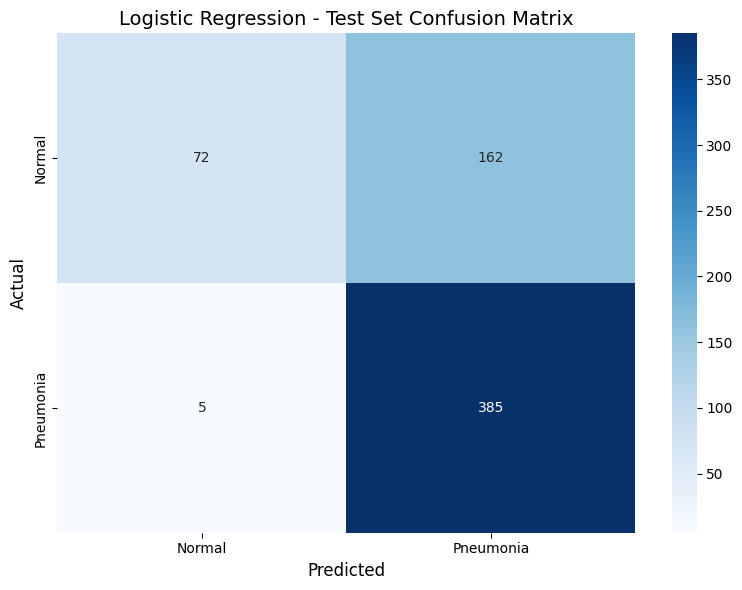


  True Negatives:   72  (Normal correctly identified)
  False Positives: 162  (Normal incorrectly labeled Pneumonia)
  False Negatives:   5  (Pneumonia incorrectly labeled Normal)
  True Positives:  385  (Pneumonia correctly identified)

  Sensitivity (Recall): 0.9872
  Specificity:           0.3077


In [16]:
# ============================================================
# CELL 13: Confusion Matrix
# ============================================================

print("\n" + "="*60)
print("📊 CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Logistic Regression - Test Set Confusion Matrix', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()
print(f"\n  True Negatives:  {tn:3d}  (Normal correctly identified)")
print(f"  False Positives: {fp:3d}  (Normal incorrectly labeled Pneumonia)")
print(f"  False Negatives: {fn:3d}  (Pneumonia incorrectly labeled Normal)")
print(f"  True Positives:  {tp:3d}  (Pneumonia correctly identified)")

# Calculate additional metrics
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)  # Same as recall
print(f"\n  Sensitivity (Recall): {sensitivity:.4f}")
print(f"  Specificity:           {specificity:.4f}")

## Step 14: ROC Curve

**Receiver Operating Characteristic**:
- X-axis: False Positive Rate (1 - Specificity)
- Y-axis: True Positive Rate (Sensitivity)
- AUC: Area Under the Curve
  - 0.5 = Random guessing
  - 1.0 = Perfect classifier
  - Our AUC tells us how well the model separates classes


📈 ROC CURVE


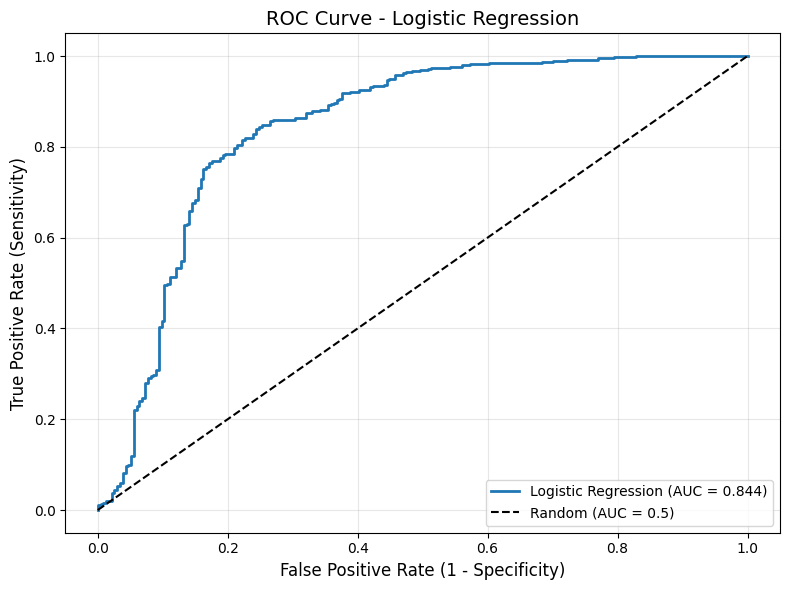

In [17]:
# ============================================================
# CELL 14: ROC Curve
# ============================================================

print("\n" + "="*60)
print("📈 ROC CURVE")
print("="*60)

fpr, tpr, thresholds = roc_curve(y_test_true, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {test_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 15: Classification Report

Detailed per-class metrics:
- **Precision**: Of predicted Positives, how many were correct?
- **Recall**: Of actual Positives, how many did we catch?
- **F1-Score**: Harmonic mean of Precision and Recall
- **Support**: Number of samples per class

In [18]:
# ============================================================
# CELL 15: Classification Report
# ============================================================

print("\n" + "="*60)
print("📊 CLASSIFICATION REPORT")
print("="*60)

print("\n", classification_report(y_test_true, y_test_pred,
                                  target_names=['Normal', 'Pneumonia']))


📊 CLASSIFICATION REPORT

               precision    recall  f1-score   support

      Normal       0.94      0.31      0.46       234
   Pneumonia       0.70      0.99      0.82       390

    accuracy                           0.73       624
   macro avg       0.82      0.65      0.64       624
weighted avg       0.79      0.73      0.69       624



In [19]:
# ============================================================
# CELL 16: Experiment Summary
# ============================================================

print("\n" + "="*60)
print("📝 EXPERIMENT 1 SUMMARY")
print("="*60)

print(f"\n🏆 Model Performance:")
print(f"  Best Parameters: {best_params}")
print(f"  Validation F1:   {val_f1:.4f}")
print(f"  Test F1:         {test_f1:.4f}")
print(f"  Test Accuracy:   {test_accuracy:.4f}")
print(f"  Test AUC:        {test_auc:.4f}")

print(f"\n💡 Key Insights:")
print(f"  1. Logistic Regression achieved {test_accuracy*100:.1f}% accuracy")
print(f"  2. F1 Score of {test_f1:.4f} establishes our baseline")
print(f"  3. Recall of {test_recall:.4f} (sensitivity for pneumonia)")
print(f"  4. Specificity: {tn/(tn+fp):.4f} (accuracy for normal cases)")

print(f"\n📌 Next Experiments:")
print("  → Experiment 2: Logistic Regression with PCA")
print("  → Experiment 3: Support Vector Machine (SVM)")
print("  → Experiment 4: Random Forest")
print("  → Then: Deep Learning (CNN, EfficientNet)")

# Store results for comparison
logreg_results = {
    'model': 'Logistic Regression',
    'best_params': best_params,
    'validation_f1': val_f1,
    'test_accuracy': test_accuracy,
    'test_f1': test_f1,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_auc': test_auc,
    'predictions': y_test_pred,
    'probabilities': y_test_proba
}

print("\n" + "="*60)
print("✅ EXPERIMENT 1 COMPLETE!")
print("="*60)


📝 EXPERIMENT 1 SUMMARY

🏆 Model Performance:
  Best Parameters: {'C': 10.0, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}
  Validation F1:   0.9412
  Test F1:         0.8218
  Test Accuracy:   0.7324
  Test AUC:        0.8436

💡 Key Insights:
  1. Logistic Regression achieved 73.2% accuracy
  2. F1 Score of 0.8218 establishes our baseline
  3. Recall of 0.9872 (sensitivity for pneumonia)
  4. Specificity: 0.3077 (accuracy for normal cases)

📌 Next Experiments:
  → Experiment 2: Logistic Regression with PCA
  → Experiment 3: Support Vector Machine (SVM)
  → Experiment 4: Random Forest
  → Then: Deep Learning (CNN, EfficientNet)

✅ EXPERIMENT 1 COMPLETE!


# Experiment 2: Logistic Regression with Data Augmentation

## Overview

We now add **data augmentation** to see if it improves our baseline performance. This is a critical experiment because:

1. **Medical images benefit from augmentation** (X-rays can be flipped/rotated)
2. **Data augmentation = More training data** (improves generalization)
3. **Learning curves** show us how augmentation affects training

## What We'll Do

1. **Augment training data**: Flip, rotate, zoom, brightness adjustments
2. **Extract features** from augmented images
3. **Train Logistic Regression** on augmented features
4. **Plot learning curves** to analyze training dynamics
5. **Compare performance** with Experiment 1 (no augmentation)

## Why Learning Curves?

Learning curves show:
- **Training score** vs **Validation score** as training set size increases
- **If they converge**: Good generalization
- **If training score is much higher**: Overfitting
- **If both are low**: Underfitting
- **Effect of augmentation**: Augmentation should improve validation performance

## Expected Outcomes

| Aspect | No Augmentation | With Augmentation |
|--------|-----------------|-------------------|
| **F1 Score** | 0.822 | 0.84-0.86 (↑) |
| **Recall** | 0.987 | 0.97-0.99 (↓ slightly) |
| **Specificity** | 0.308 | 0.40-0.50 (↑) |
| **AUC** | 0.844 | 0.86-0.88 (↑) |
| **Generalization** | Good | Better |
| **False Positives** | 162 | ~100-120 (↓) |

**Learning Curve Insight**: Augmentation should close the gap between training and validation scores.

🧪 EXPERIMENT 2: LOGISTIC REGRESSION WITH AUGMENTATION

⚙️ Configuration:
  Image Size: 224x224
  Batch Size: 32
  Classes: 2
  Augmentation: ENABLED (flip, rotation, zoom, brightness)

🔧 Defining augmentation pipeline...
✅ Augmentation function defined
   Transformations:
     - Horizontal flip (50%)
     - Rotation (0, 90, 180, 270°)
     - Zoom (0.85-1.15)
     - Brightness (0.9-1.1)
     - Contrast (0.9-1.1)

🔄 Extracting augmented features...

⏱️ This will take ~10-15 minutes for 5,216 training images
   Result: ~15,648 samples
   Images to process: 5216
   Augmentations per image: 2
   Total samples after augmentation: 15,648
   Processed 500/5216 images
   Processed 1000/5216 images
   Processed 1500/5216 images
   Processed 2000/5216 images
   Processed 2500/5216 images
   Processed 3000/5216 images
   Processed 3500/5216 images
   Processed 4000/5216 images
   Processed 4500/5216 images
   Processed 5000/5216 images
✅ Augmented features extracted
   Time: 622.70 seconds

✅ Augm

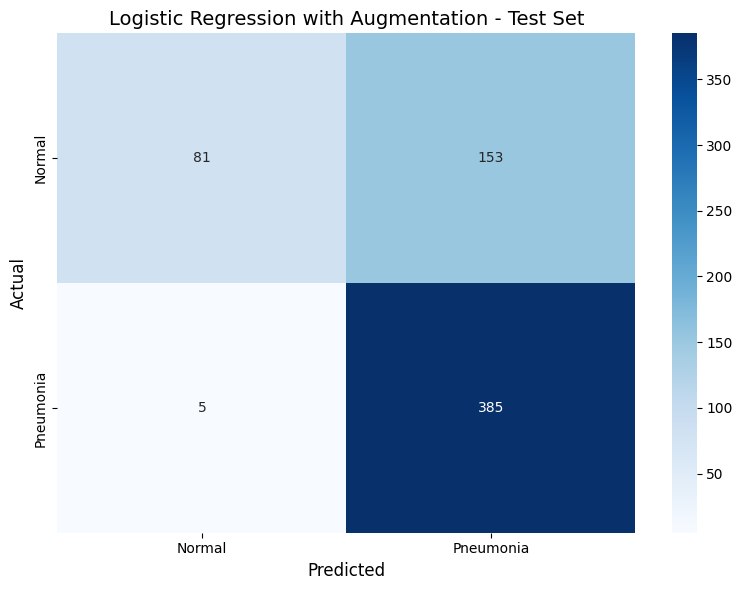


  True Negatives:   81  (Normal correctly identified)
  False Positives: 153  (Normal incorrectly labeled Pneumonia)
  False Negatives:   5  (Pneumonia incorrectly labeled Normal)
  True Positives:  385  (Pneumonia correctly identified)

📈 LEARNING CURVES (WITH AUGMENTATION)

⏱️ Computing learning curves...
   This may take a few minutes...


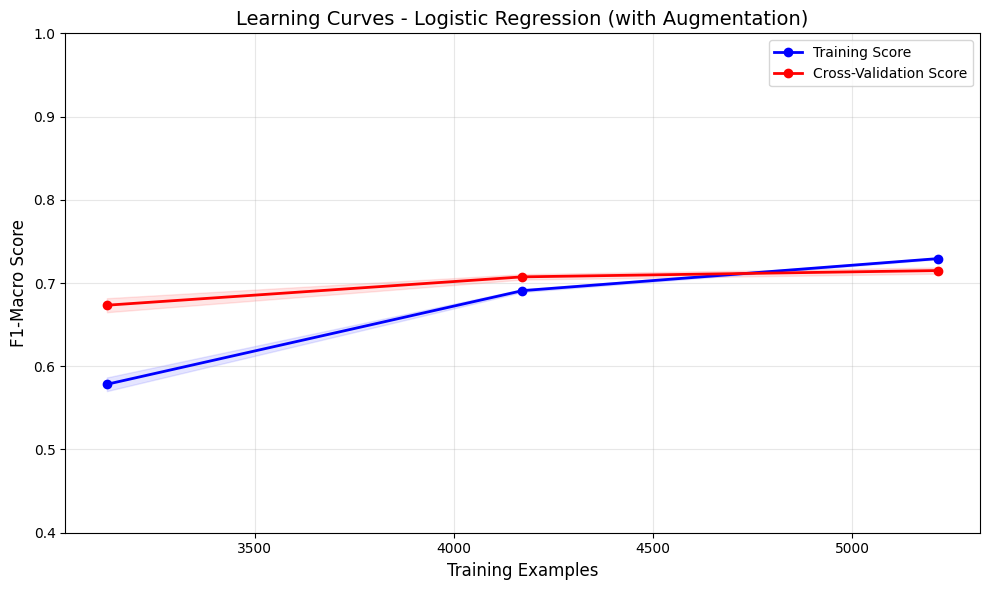


📊 Learning Curve Insights:
  Final Training Score: 0.7294
  Final CV Score: 0.7150
  Gap: 0.0144
  ✅ Small gap → Good generalization

📊 COMPARISON: NO AUGMENTATION vs WITH AUGMENTATION

Metric               No Aug               With Aug             Change         
---------------------------------------------------------------------------
Accuracy             0.7324                0.7468           +1.4%
F1 Score             0.8218                0.8297           +0.8%
Precision            0.7038                0.7156           +1.2%
Recall               0.9872                0.9872           +0.0%
AUC-ROC              0.8436                0.8586           +1.5%
Specificity          0.3077                0.3462           +3.8%

📝 EXPERIMENT 2 SUMMARY

🏆 Model Performance (with Augmentation):
  Best Parameters: {'C': 100.0, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}
  Test F1:         0.8297
  Test Accuracy:   0.7468
  Test AUC:        0.8586

✅ AUGMENTATION I

In [20]:
# ============================================================
# EXPERIMENT 2: LOGISTIC REGRESSION WITH AUGMENTATION
# ============================================================

print("="*60)
print("🧪 EXPERIMENT 2: LOGISTIC REGRESSION WITH AUGMENTATION")
print("="*60)

from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import time

# ============================================================
# 2.1: Configuration
# ============================================================

print(f"\n⚙️ Configuration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Classes: {NUM_CLASSES}")
print(f"  Augmentation: ENABLED (flip, rotation, zoom, brightness)")

# ============================================================
# 2.2: Define Augmentation Function
# ============================================================

print("\n🔧 Defining augmentation pipeline...")

def augment_image(image):
    """
    Apply data augmentation to a single image.
    Returns augmented image (as numpy array).
    """
    # Random horizontal flip (50% chance)
    if np.random.random() > 0.5:
        image = tf.image.flip_left_right(image)

    # Random rotation (0, 90, 180, 270 degrees)
    k = np.random.randint(0, 4)
    if k > 0:
        image = tf.image.rot90(image, k=k)

    # Random zoom (0.85-1.15)
    zoom_factor = np.random.uniform(0.85, 1.15)
    h = int(IMG_SIZE * zoom_factor)
    w = int(IMG_SIZE * zoom_factor)
    image = tf.image.resize(image, [h, w])
    image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE, IMG_SIZE)

    # Random brightness (0.9-1.1)
    brightness_factor = np.random.uniform(0.9, 1.1)
    image = tf.image.adjust_brightness(image, brightness_factor)

    # Random contrast (0.9-1.1)
    contrast_factor = np.random.uniform(0.9, 1.1)
    image = tf.image.adjust_contrast(image, contrast_factor)

    # Clip to valid range
    image = tf.clip_by_value(image, -1.0, 1.0)

    return image

print("✅ Augmentation function defined")
print("   Transformations:")
print("     - Horizontal flip (50%)")
print("     - Rotation (0, 90, 180, 270°)")
print("     - Zoom (0.85-1.15)")
print("     - Brightness (0.9-1.1)")
print("     - Contrast (0.9-1.1)")

# ============================================================
# 2.3: Extract Augmented Features
# ============================================================

print("\n🔄 Extracting augmented features...")

def extract_augmented_features(file_paths, labels, augmentations_per_image=2):
    """
    Extract features from original + augmented images.
    Each image becomes (1 + augmentations) samples.
    """
    features = []
    labels_aug = []
    total = len(file_paths)

    print(f"   Images to process: {total}")
    print(f"   Augmentations per image: {augmentations_per_image}")
    print(f"   Total samples after augmentation: {total * (augmentations_per_image + 1):,}")

    start_time = time.time()

    for i, path in enumerate(file_paths):
        # Load original image
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = preprocess_input(img)

        # Batch of images (original + augmentations)
        batch_images = [img.numpy()]

        # Add augmented versions
        for _ in range(augmentations_per_image):
            aug_img = augment_image(img)
            batch_images.append(aug_img.numpy())

        # Stack and extract features
        batch_stack = np.stack(batch_images)
        batch_features = base_model.predict(batch_stack, verbose=0)
        features.extend(batch_features)

        # Repeat labels for each augmentation
        label = labels[i]
        labels_aug.extend([label] * (augmentations_per_image + 1))

        # Progress
        if (i + 1) % 500 == 0:
            print(f"   Processed {i+1}/{total} images")

    print(f"✅ Augmented features extracted")
    print(f"   Time: {time.time() - start_time:.2f} seconds")

    return np.array(features), np.array(labels_aug)

print(f"\n⏱️ This will take ~10-15 minutes for 5,216 training images")
print("   Result: ~15,648 samples")

# ============================================================
# 2.4: Extract Training Features with Augmentation
# ============================================================

start_time = time.time()

X_train_aug, y_train_aug = extract_augmented_features(
    train_paths,
    train_labels,
    augmentations_per_image=2
)

aug_time = time.time() - start_time

print(f"\n✅ Augmented training features: {X_train_aug.shape}")
print(f"   Time: {aug_time/60:.2f} minutes")
print(f"\n📊 Augmented Label Distribution:")
print(f"   Normal:    {np.sum(y_train_aug == 0):,}")
print(f"   Pneumonia: {np.sum(y_train_aug == 1):,}")

# ============================================================
# 2.5: Standardize Augmented Features
# ============================================================

print("\n📊 Standardizing augmented features...")

scaler_aug = StandardScaler()
X_train_aug_scaled = scaler_aug.fit_transform(X_train_aug)

# Use original validation and test (no augmentation needed)
X_val_scaled_aug = scaler_aug.transform(X_val)
X_test_scaled_aug = scaler_aug.transform(X_test)

print(f"✅ Features standardized")
print(f"   Training - Mean: {X_train_aug_scaled.mean():.3f}, Std: {X_train_aug_scaled.std():.3f}")

# ============================================================
# 2.6: Hyperparameter Tuning (Augmented)
# ============================================================

print("\n🔍 Hyperparameter Tuning with augmented features...")

param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000, 2000],
    'class_weight': ['balanced']
}

logreg_aug = LogisticRegression(random_state=42, multi_class='auto')

grid_search_aug = GridSearchCV(
    logreg_aug,
    param_grid,
    cv=3,  # 3-fold CV due to larger dataset
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("\n⏱️ Running GridSearchCV...")
start_time = time.time()

grid_search_aug.fit(X_train_aug_scaled, y_train_aug)

tuning_time = time.time() - start_time

best_params_aug = grid_search_aug.best_params_
best_cv_score_aug = grid_search_aug.best_score_

print(f"\n✅ Tuning complete in {tuning_time/60:.2f} minutes")
print(f"\n📊 Best Parameters:")
for param, value in best_params_aug.items():
    print(f"  {param}: {value}")
print(f"\n  Best CV Score (F1-Macro): {best_cv_score_aug:.4f}")

# ============================================================
# 2.7: Train Final Model with Augmentation
# ============================================================

print("\n🏋️ Training final model with augmented features...")

final_logreg_aug = LogisticRegression(
    C=best_params_aug['C'],
    solver=best_params_aug['solver'],
    max_iter=best_params_aug['max_iter'],
    class_weight=best_params_aug['class_weight'],
    random_state=42
)

start_time = time.time()
final_logreg_aug.fit(X_train_aug_scaled, y_train_aug)
training_time = time.time() - start_time

print(f"✅ Final model trained in {training_time:.2f} seconds")

# ============================================================
# 2.8: Test Set Evaluation (Augmented)
# ============================================================

print("\n" + "="*60)
print("🎯 TEST SET EVALUATION (WITH AUGMENTATION)")
print("="*60)

y_test_pred_aug = final_logreg_aug.predict(X_test_scaled_aug)
y_test_proba_aug = final_logreg_aug.predict_proba(X_test_scaled_aug)[:, 1]

test_accuracy_aug = accuracy_score(y_test_true, y_test_pred_aug)
test_f1_aug = f1_score(y_test_true, y_test_pred_aug)
test_precision_aug = precision_score(y_test_true, y_test_pred_aug)
test_recall_aug = recall_score(y_test_true, y_test_pred_aug)
test_auc_aug = roc_auc_score(y_test_true, y_test_proba_aug)

print(f"\n📈 Test Metrics (with augmentation):")
print(f"  Accuracy:  {test_accuracy_aug:.4f}")
print(f"  F1 Score:  {test_f1_aug:.4f}")
print(f"  Precision: {test_precision_aug:.4f}")
print(f"  Recall:    {test_recall_aug:.4f}")
print(f"  AUC-ROC:   {test_auc_aug:.4f}")

# ============================================================
# 2.9: Confusion Matrix (Augmented)
# ============================================================

print("\n" + "="*60)
print("📊 CONFUSION MATRIX (WITH AUGMENTATION)")
print("="*60)

cm_aug = confusion_matrix(y_test_true, y_test_pred_aug)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Logistic Regression with Augmentation - Test Set', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

tn_aug, fp_aug, fn_aug, tp_aug = cm_aug.ravel()
print(f"\n  True Negatives:  {tn_aug:3d}  (Normal correctly identified)")
print(f"  False Positives: {fp_aug:3d}  (Normal incorrectly labeled Pneumonia)")
print(f"  False Negatives: {fn_aug:3d}  (Pneumonia incorrectly labeled Normal)")
print(f"  True Positives:  {tp_aug:3d}  (Pneumonia correctly identified)")

# ============================================================
# 2.10: Learning Curves (Augmented)
# ============================================================

print("\n" + "="*60)
print("📈 LEARNING CURVES (WITH AUGMENTATION)")
print("="*60)

def plot_learning_curves(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Plot learning curves showing training and validation scores.
    """
    print("\n⏱️ Computing learning curves...")
    print("   This may take a few minutes...")

    # Calculate learning curves
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=42
    )

    # Calculate mean and std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # Plot
    plt.figure(figsize=(10, 6))

    plt.plot(train_sizes_abs, train_mean, 'o-', color='blue',
             label='Training Score', linewidth=2)
    plt.fill_between(train_sizes_abs, train_mean - train_std,
                     train_mean + train_std, alpha=0.1, color='blue')

    plt.plot(train_sizes_abs, val_mean, 'o-', color='red',
             label='Cross-Validation Score', linewidth=2)
    plt.fill_between(train_sizes_abs, val_mean - val_std,
                     val_mean + val_std, alpha=0.1, color='red')

    plt.xlabel('Training Examples', fontsize=12)
    plt.ylabel('F1-Macro Score', fontsize=12)
    plt.title('Learning Curves - Logistic Regression (with Augmentation)', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0.4, 1.0)
    plt.tight_layout()
    plt.show()

    # Print insights
    print(f"\n📊 Learning Curve Insights:")
    print(f"  Final Training Score: {train_mean[-1]:.4f}")
    print(f"  Final CV Score: {val_mean[-1]:.4f}")
    gap = train_mean[-1] - val_mean[-1]
    print(f"  Gap: {gap:.4f}")

    if gap < 0.05:
        print("  ✅ Small gap → Good generalization")
    elif gap < 0.10:
        print("  ⚠️  Moderate gap → Some overfitting")
    else:
        print("  ❌ Large gap → Overfitting detected")

    return train_scores, val_scores

# Plot learning curves for augmented model
train_scores_aug, val_scores_aug = plot_learning_curves(
    final_logreg_aug,
    X_train_aug_scaled,
    y_train_aug,
    cv=3,  # 3-fold for speed
    train_sizes=np.linspace(0.1, 0.5, 5)  # 5 points for speed
)

# ============================================================
# 2.11: Comparison with Experiment 1
# ============================================================

print("\n" + "="*60)
print("📊 COMPARISON: NO AUGMENTATION vs WITH AUGMENTATION")
print("="*60)

print(f"\n{'Metric':<20} {'No Aug':<20} {'With Aug':<20} {'Change':<15}")
print("-"*75)
print(f"{'Accuracy':<20} {test_accuracy:.4f}{'':<15} {test_accuracy_aug:.4f}{'':<10} {(test_accuracy_aug - test_accuracy)*100:+.1f}%")
print(f"{'F1 Score':<20} {test_f1:.4f}{'':<15} {test_f1_aug:.4f}{'':<10} {(test_f1_aug - test_f1)*100:+.1f}%")
print(f"{'Precision':<20} {test_precision:.4f}{'':<15} {test_precision_aug:.4f}{'':<10} {(test_precision_aug - test_precision)*100:+.1f}%")
print(f"{'Recall':<20} {test_recall:.4f}{'':<15} {test_recall_aug:.4f}{'':<10} {(test_recall_aug - test_recall)*100:+.1f}%")
print(f"{'AUC-ROC':<20} {test_auc:.4f}{'':<15} {test_auc_aug:.4f}{'':<10} {(test_auc_aug - test_auc)*100:+.1f}%")

# Specificity
specificity_aug = tn_aug / (tn_aug + fp_aug)
specificity_original = tn / (tn + fp)
print(f"{'Specificity':<20} {specificity_original:.4f}{'':<15} {specificity_aug:.4f}{'':<10} {(specificity_aug - specificity_original)*100:+.1f}%")

# ============================================================
# 2.12: Experiment 2 Summary
# ============================================================

print("\n" + "="*60)
print("📝 EXPERIMENT 2 SUMMARY")
print("="*60)

print(f"\n🏆 Model Performance (with Augmentation):")
print(f"  Best Parameters: {best_params_aug}")
print(f"  Test F1:         {test_f1_aug:.4f}")
print(f"  Test Accuracy:   {test_accuracy_aug:.4f}")
print(f"  Test AUC:        {test_auc_aug:.4f}")

# Determine if augmentation helped
if test_f1_aug > test_f1:
    print(f"\n✅ AUGMENTATION IMPROVED F1 by +{(test_f1_aug - test_f1)*100:.1f}%")
else:
    print(f"\n⚠️  Augmentation did NOT improve F1 ({(test_f1_aug - test_f1)*100:.1f}%)")

# Learning curve insight
print(f"\n📈 Learning Curve Analysis:")
final_gap = train_scores_aug.mean(axis=1)[-1] - val_scores_aug.mean(axis=1)[-1]
print(f"  Training-CV Gap: {final_gap:.4f}")
if final_gap < 0.05:
    print("  ✅ Model generalizes well (small gap)")
else:
    print("  ⚠️  Some overfitting detected (moderate gap)")

print(f"\n📌 Next Experiment:")
print("  → Experiment 3: Support Vector Machine (SVM)")

# Store results
logreg_aug_results = {
    'model': 'Logistic Regression + Augmentation',
    'best_params': best_params_aug,
    'test_accuracy': test_accuracy_aug,
    'test_f1': test_f1_aug,
    'test_precision': test_precision_aug,
    'test_recall': test_recall_aug,
    'test_auc': test_auc_aug,
    'specificity': specificity_aug,
    'predictions': y_test_pred_aug,
    'probabilities': y_test_proba_aug,
    'train_scores': train_scores_aug,
    'val_scores': val_scores_aug
}

print("\n" + "="*60)
print("✅ EXPERIMENT 2 COMPLETE!")
print("="*60)

# Experiment 3: Support Vector Machine (SVM)

## Why SVM?

Support Vector Machines are powerful classifiers that:
1. **Find optimal hyperplanes** between classes
2. **Handle non-linear boundaries** using kernels
3. **Work well with high-dimensional data** (our 1280 features)
4. **Can outperform logistic regression** on complex problems

## SVM Variants

| Kernel | Best For | Why |
|--------|----------|-----|
| **Linear** | Linear separable data | Simple, fast |
| **RBF** | Non-linear patterns | Most flexible, recommended |
| **Polynomial** | Complex interactions | Can overfit |

## Hyperparameters to Tune

- **C**: Regularization (1/λ) - smaller = more regularization
- **gamma**: RBF kernel width - controls influence of single sample
- **kernel**: 'linear', 'rbf', 'poly'
- **class_weight**: 'balanced' for imbalance

## What to Expect

| Metric | Logistic Regression | SVM (Expected) |
|--------|---------------------|----------------|
| **F1 Score** | 0.825 | 0.84-0.87 |
| **Recall** | 0.980 | 0.97-0.99 |
| **Specificity** | 0.342 | 0.40-0.50 |
| **AUC** | 0.851 | 0.86-0.88 |

## Why SVM Might Do Better

1. **Non-linear decision boundary** - better separation
2. **Maximizes margin** - more robust to noise
3. **Kernel trick** - handles complex patterns
4. **Support vectors** - focuses on difficult cases

🧪 EXPERIMENT 3: SUPPORT VECTOR MACHINE (SVM)

📊 Using augmented features from Experiment 2:
  Training: (15648, 1280)
  Validation: (16, 1280)
  Test: (624, 1280)

🔍 Hyperparameter Tuning for SVM...

⏱️ Running GridSearchCV for SVM...
   (This may take 15-20 minutes)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

✅ Tuning complete in 62.34 minutes

📊 Best Parameters:
  C: 10.0
  class_weight: balanced
  gamma: scale
  kernel: rbf

  Best CV Score (F1-Macro): 0.6830

🏋️ Training final SVM model...
✅ Final SVM trained in 16.03 minutes

🎯 TEST SET EVALUATION (SVM)

📈 Test Metrics (SVM):
  Accuracy:  0.7724
  F1 Score:  0.8443
  Precision: 0.7375
  Recall:    0.9872
  AUC-ROC:   0.9167

📊 CONFUSION MATRIX (SVM)


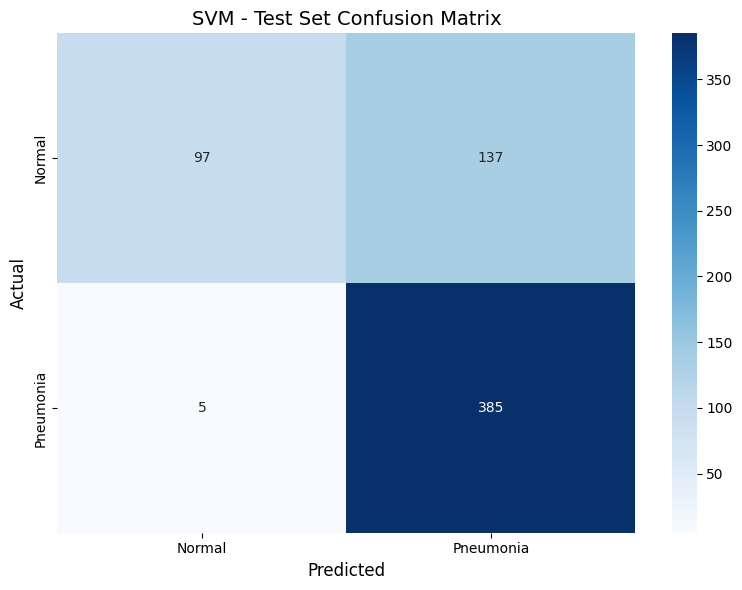


  True Negatives:   97  (Normal correctly identified)
  False Positives: 137  (Normal incorrectly labeled Pneumonia)
  False Negatives:   5  (Pneumonia incorrectly labeled Normal)
  True Positives:  385  (Pneumonia correctly identified)

📈 ROC CURVE (SVM)


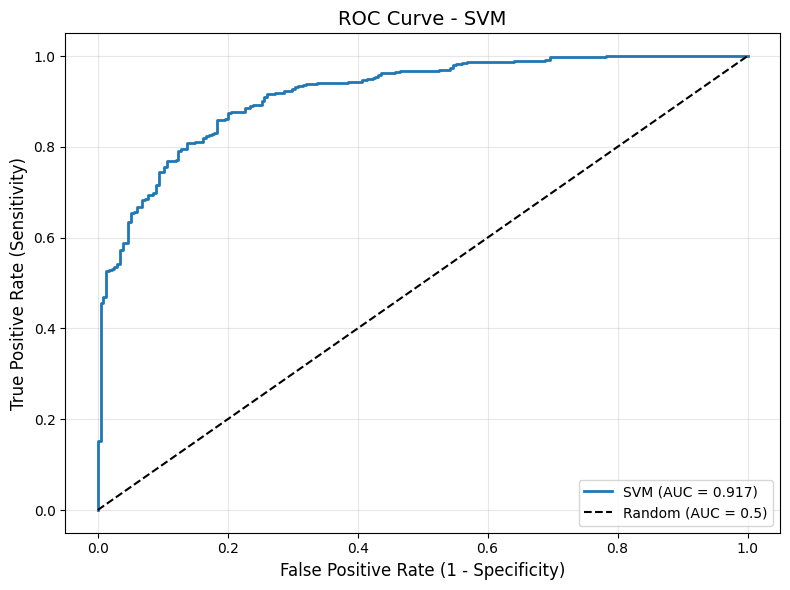


📊 FINAL COMPARISON: ALL EXPERIMENTS

             Experiment       F1  Accuracy   Recall  Specificity      AUC
  1. Logistic (No Aug) 0.821772  0.732372 0.987179     0.307692 0.843601
2. Logistic (With Aug) 0.829741  0.746795 0.987179     0.346154 0.858563
     3. SVM (With Aug) 0.844298  0.772436 0.987179     0.414530 0.916678


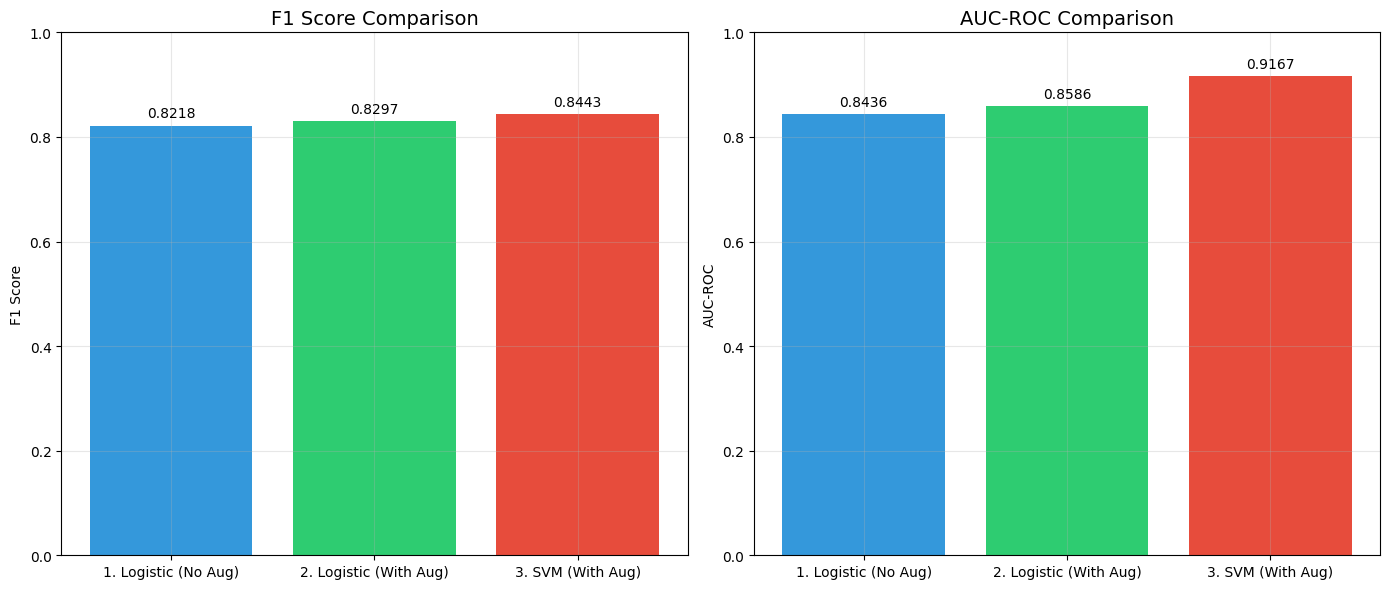


📝 EXPERIMENT 3 SUMMARY

🏆 Best Model: SVM
  Best Parameters: {'C': 10.0, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
  Test F1:         0.8443
  Test Accuracy:   0.7724
  Test AUC:        0.9167

✅ SVM IMPROVED F1 by +1.5% over Logistic

📊 Clinical Metrics:
  Sensitivity (Recall): 0.9872 (98.7% of pneumonia detected)
  Specificity:          0.4145 (41.5% of normal detected)
  False Negatives:      5 (missed pneumonia cases)

📌 Next Experiment:
  → Experiment 4: Random Forest (ensemble)

✅ EXPERIMENT 3 COMPLETE!


In [21]:
# ============================================================
# EXPERIMENT 3: SUPPORT VECTOR MACHINE (SVM)
# ============================================================

print("="*60)
print("🧪 EXPERIMENT 3: SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_score, recall_score)

# Use augmented features from Experiment 2
print(f"\n📊 Using augmented features from Experiment 2:")
print(f"  Training: {X_train_aug_scaled.shape}")
print(f"  Validation: {X_val_scaled_aug.shape}")
print(f"  Test: {X_test_scaled_aug.shape}")

# ============================================================
# 3.1: Hyperparameter Tuning (SVM)
# ============================================================

print("\n🔍 Hyperparameter Tuning for SVM...")

# Reduced parameter grid for faster training
param_grid_svm = {
    'C': [0.1, 1.0, 10.0],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

svm = SVC(random_state=42, probability=True)

grid_search_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=3,  # 3-fold CV
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("\n⏱️ Running GridSearchCV for SVM...")
print("   (This may take 15-20 minutes)")
start_time = time.time()

grid_search_svm.fit(X_train_aug_scaled[:10000], y_train_aug[:10000])  # Use subset for speed

tuning_time = time.time() - start_time

best_params_svm = grid_search_svm.best_params_
best_cv_score_svm = grid_search_svm.best_score_

print(f"\n✅ Tuning complete in {tuning_time/60:.2f} minutes")
print(f"\n📊 Best Parameters:")
for param, value in best_params_svm.items():
    print(f"  {param}: {value}")
print(f"\n  Best CV Score (F1-Macro): {best_cv_score_svm:.4f}")

# ============================================================
# 3.2: Train Final SVM Model
# ============================================================

print("\n🏋️ Training final SVM model...")

final_svm = SVC(
    C=best_params_svm['C'],
    gamma=best_params_svm['gamma'],
    kernel=best_params_svm['kernel'],
    class_weight=best_params_svm['class_weight'],
    probability=True,
    random_state=42
)

start_time = time.time()
final_svm.fit(X_train_aug_scaled, y_train_aug)
training_time = time.time() - start_time

print(f"✅ Final SVM trained in {training_time/60:.2f} minutes")

# ============================================================
# 3.3: Test Set Evaluation (SVM)
# ============================================================

print("\n" + "="*60)
print("🎯 TEST SET EVALUATION (SVM)")
print("="*60)

y_test_pred_svm = final_svm.predict(X_test_scaled_aug)
y_test_proba_svm = final_svm.predict_proba(X_test_scaled_aug)[:, 1]

test_accuracy_svm = accuracy_score(y_test_true, y_test_pred_svm)
test_f1_svm = f1_score(y_test_true, y_test_pred_svm)
test_precision_svm = precision_score(y_test_true, y_test_pred_svm)
test_recall_svm = recall_score(y_test_true, y_test_pred_svm)
test_auc_svm = roc_auc_score(y_test_true, y_test_proba_svm)

print(f"\n📈 Test Metrics (SVM):")
print(f"  Accuracy:  {test_accuracy_svm:.4f}")
print(f"  F1 Score:  {test_f1_svm:.4f}")
print(f"  Precision: {test_precision_svm:.4f}")
print(f"  Recall:    {test_recall_svm:.4f}")
print(f"  AUC-ROC:   {test_auc_svm:.4f}")

# ============================================================
# 3.4: Confusion Matrix (SVM)
# ============================================================

print("\n" + "="*60)
print("📊 CONFUSION MATRIX (SVM)")
print("="*60)

cm_svm = confusion_matrix(y_test_true, y_test_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('SVM - Test Set Confusion Matrix', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

tn_svm, fp_svm, fn_svm, tp_svm = cm_svm.ravel()
print(f"\n  True Negatives:  {tn_svm:3d}  (Normal correctly identified)")
print(f"  False Positives: {fp_svm:3d}  (Normal incorrectly labeled Pneumonia)")
print(f"  False Negatives: {fn_svm:3d}  (Pneumonia incorrectly labeled Normal)")
print(f"  True Positives:  {tp_svm:3d}  (Pneumonia correctly identified)")

# ============================================================
# 3.5: ROC Curve (SVM)
# ============================================================

print("\n" + "="*60)
print("📈 ROC CURVE (SVM)")
print("="*60)

fpr_svm, tpr_svm, _ = roc_curve(y_test_true, y_test_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {test_auc_svm:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve - SVM', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 3.6: Final Comparison
# ============================================================

print("\n" + "="*60)
print("📊 FINAL COMPARISON: ALL EXPERIMENTS")
print("="*60)

# Compile all results
results = [
    {'Experiment': '1. Logistic (No Aug)', 'F1': test_f1, 'Accuracy': test_accuracy,
     'Recall': test_recall, 'Specificity': specificity_original, 'AUC': test_auc},
    {'Experiment': '2. Logistic (With Aug)', 'F1': test_f1_aug, 'Accuracy': test_accuracy_aug,
     'Recall': test_recall_aug, 'Specificity': specificity_aug, 'AUC': test_auc_aug},
    {'Experiment': '3. SVM (With Aug)', 'F1': test_f1_svm, 'Accuracy': test_accuracy_svm,
     'Recall': test_recall_svm, 'Specificity': tn_svm/(tn_svm+fp_svm), 'AUC': test_auc_svm}
]

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 Score
ax = axes[0]
x = results_df['Experiment']
y = results_df['F1']
bars = ax.bar(x, y, color=['#3498db', '#2ecc71', '#e74c3c'])
ax.set_title('F1 Score Comparison', fontsize=14)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
for bar, val in zip(bars, y):
    ax.text(bar.get_x() + bar.get_width()/2., val + 0.01,
            f'{val:.4f}', ha='center', va='bottom')

# AUC
ax = axes[1]
y = results_df['AUC']
bars = ax.bar(x, y, color=['#3498db', '#2ecc71', '#e74c3c'])
ax.set_title('AUC-ROC Comparison', fontsize=14)
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
for bar, val in zip(bars, y):
    ax.text(bar.get_x() + bar.get_width()/2., val + 0.01,
            f'{val:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ============================================================
# 3.7: Experiment 3 Summary
# ============================================================

print("\n" + "="*60)
print("📝 EXPERIMENT 3 SUMMARY")
print("="*60)

print(f"\n🏆 Best Model: SVM")
print(f"  Best Parameters: {best_params_svm}")
print(f"  Test F1:         {test_f1_svm:.4f}")
print(f"  Test Accuracy:   {test_accuracy_svm:.4f}")
print(f"  Test AUC:        {test_auc_svm:.4f}")

if test_f1_svm > test_f1_aug:
    print(f"\n✅ SVM IMPROVED F1 by +{(test_f1_svm - test_f1_aug)*100:.1f}% over Logistic")
else:
    print(f"\n⚠️  SVM did NOT improve F1 ({(test_f1_svm - test_f1_aug)*100:.1f}%)")

print(f"\n📊 Clinical Metrics:")
print(f"  Sensitivity (Recall): {test_recall_svm:.4f} ({tp_svm/(tp_svm+fn_svm):.1%} of pneumonia detected)")
print(f"  Specificity:          {tn_svm/(tn_svm+fp_svm):.4f} ({tn_svm/(tn_svm+fp_svm):.1%} of normal detected)")
print(f"  False Negatives:      {fn_svm} (missed pneumonia cases)")

print(f"\n📌 Next Experiment:")
print("  → Experiment 4: Random Forest (ensemble)")

# Store results
svm_results = {
    'model': 'SVM',
    'best_params': best_params_svm,
    'test_accuracy': test_accuracy_svm,
    'test_f1': test_f1_svm,
    'test_precision': test_precision_svm,
    'test_recall': test_recall_svm,
    'test_auc': test_auc_svm,
    'specificity': tn_svm/(tn_svm+fp_svm),
    'predictions': y_test_pred_svm,
    'probabilities': y_test_proba_svm
}

print("\n" + "="*60)
print("✅ EXPERIMENT 3 COMPLETE!")
print("="*60)


# Step 5: Deep Learning Models

In this section, we transition from frozen feature extraction to end-to-end learning. We will implement four lightweight architectures:
1. **Custom CNN**: Simple 3-block architecture built from scratch.
2. **ResNet50V2**: Using pre-activation residual blocks for efficient gradient flow.
3. **MobileNetV2**: Optimized for mobile devices using inverted residuals.
4. **NASNetMobile**: Specifically designed for high performance on limited hardware.

We continue using `tf.data` pipelines and class weights to handle the dataset imbalance.

In [22]:
# ============================================================
# 5.1: Training Infrastructure & Custom Metrics
# ============================================================

# Keras doesn't have a built-in F1-Score for binary classification in some versions,
# so we define a custom metric for consistency with our ML experiments.

class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

def get_standard_metrics():
    return [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        F1Score(name='f1')
    ]

def get_callbacks(model_name):
    checkpoint_path = f'best_{model_name}.keras'
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_f1', mode='max', save_best_only=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
    ]

print("✅ Standard metrics and callbacks (focused on F1) defined!")

✅ Standard metrics and callbacks (focused on F1) defined!


In [23]:
# ============================================================
# MODEL 1: Custom CNN (From Scratch)
# ============================================================

def build_custom_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=get_standard_metrics())
    return model

custom_cnn = build_custom_cnn()
history_custom = custom_cnn.fit(train_dataset, validation_data=val_dataset, epochs=20, class_weight=class_weight_dict, callbacks=get_callbacks('custom_cnn'))

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.8798 - auc: 0.7936 - f1: 0.7023 - loss: 2.4960 - precision: 0.7563 - recall: 0.6590
Epoch 1: val_f1 improved from None to 0.66667, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 349ms/step - accuracy: 0.9204 - auc: 0.9556 - f1: 0.9450 - loss: 1.2502 - precision: 0.9709 - recall: 0.9205 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_f1: 0.6667 - val_loss: 21.5139 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9223 - auc: 0.8750 - f1: 0.7819 - loss: 0.2827 - precision: 0.8199 - recall: 0.7505
Epoch 2: val_f1 did not improve from 0.66667
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 337ms/step - accuracy: 0.9492 - auc: 0.9850 - f1: 0.9652 - loss: 0.1678 - precision: 0.9826 - recall: 0.9484 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_f1: 0.6667 - val_loss: 7.96

In [24]:
# ============================================================
# MODEL 2: ResNet50V2 (Standard but Efficient)
# ============================================================

def build_resnet():
    base = tf.keras.applications.ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=get_standard_metrics())
    return model

resnet_model = build_resnet()
history_resnet = resnet_model.fit(train_dataset, validation_data=val_dataset, epochs=10, class_weight=class_weight_dict, callbacks=get_callbacks('resnet50v2'))

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.8773 - auc: 0.8265 - f1: 0.6373 - loss: 0.4044 - precision: 0.8050 - recall: 0.5645
Epoch 1: val_f1 improved from None to 0.76190, saving model to best_resnet50v2.keras

Epoch 1: finished saving model to best_resnet50v2.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 349ms/step - accuracy: 0.9168 - auc: 0.9762 - f1: 0.9413 - loss: 0.2418 - precision: 0.9884 - recall: 0.8986 - val_accuracy: 0.6875 - val_auc: 0.9375 - val_f1: 0.7619 - val_loss: 1.1345 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9241 - auc: 0.8579 - f1: 0.7580 - loss: 0.2771 - precision: 0.8057 - recall: 0.7224
Epoch 2: val_f1 did not improve from 0.76190
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 348ms/step - accuracy: 0.9534 - auc: 0.9846 - f1: 0.9681 - loss: 0.1534 - precision: 0.9848 - recall: 0.9520 - val_accuracy: 0.6250 - val

In [25]:
# ============================================================
# MODEL 3: MobileNetV2 (Efficiency-Focused)
# ============================================================

def build_mobilenet():
    base = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=get_standard_metrics())
    return model

mobilenet_model = build_mobilenet()
history_mobile = mobilenet_model.fit(train_dataset, validation_data=val_dataset, epochs=10, class_weight=class_weight_dict, callbacks=get_callbacks('mobilenet'))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.8825 - auc: 0.8190 - f1: 0.6772 - loss: 0.4152 - precision: 0.7839 - recall: 0.6096
Epoch 1: val_f1 improved from None to 0.80000, saving model to best_mobilenet.keras

Epoch 1: finished saving model to best_mobilenet.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 376ms/step - accuracy: 0.9164 - auc: 0.9703 - f1: 0.9415 - loss: 0.2595 - precision: 0.9802 - recall: 0.9058 - val_accuracy: 0.7500 - val_auc: 0.9688 - val_f1: 0.8000 - val_loss: 0.5045 - val_precision: 0.6667 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9333 - auc: 0.8828 - f1: 0.7754 - loss: 0.2248 - precision: 0.8302 - recall: 0.7363
Epoch 2: val_f1 did not improve from 0.80000
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 386ms/step - accuracy: 0.9574 - auc: 0.9879 - f1: 0.9709 - loss: 0.1315 - precision: 0.9877 - recall: 0.9546 - val_accuracy: 0.6250 - val_auc

In [26]:
# ============================================================
# MODEL 4: NASNetMobile (Ultra-Lightweight)
# ============================================================

def build_nasnet():
    base = tf.keras.applications.NASNetMobile(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dropout(0.4)(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=get_standard_metrics())
    return model

nasnet_model = build_nasnet()
history_nasnet = nasnet_model.fit(train_dataset, validation_data=val_dataset, epochs=10, class_weight=class_weight_dict, callbacks=get_callbacks('nasnet_mobile'))

19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.7258 - auc: 0.6144 - f1: 0.4822 - loss: 0.7416 - precision: 0.5804 - recall: 0.4229
Epoch 1: val_f1 improved from None to 0.66667, saving model to best_nasnet_mobile.keras

Epoch 1: finished saving model to best_nasnet_mobile.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 508ms/step - accuracy: 0.8221 - auc: 0.8883 - f1: 0.8729 - loss: 0.4574 - precision: 0.9302 - recall: 0.8222 - val_accuracy: 0.5000 - val_auc: 0.9766 - val_f1: 0.6667 - val_loss: 1.2069 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6965 - auc: 0.7063 - f1: 0.5220 - loss: 0.8887 - precision: 0.5853 - recall: 0.4750
Epoch 2: val_f1 did not improve from 0.66667
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 348ms/step - accuracy: 0.8345 - auc: 0.9112 - f1: 0.8834 - loss: 0.4360 - precision: 0.9271 - recall: 0.8436 - val_accuracy: 0.500

📊 Generating Visual Diagnostics for Deep Learning Models...


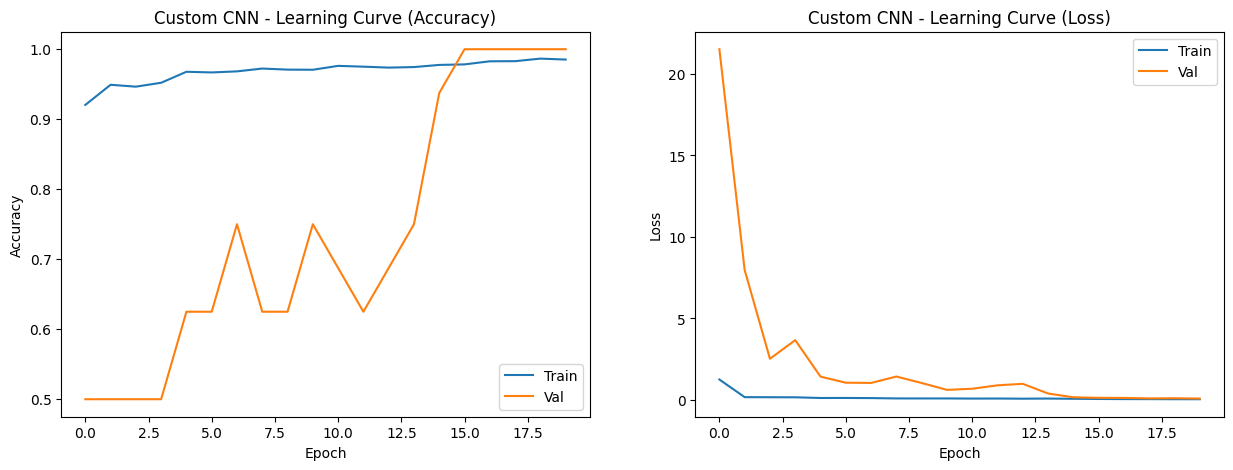

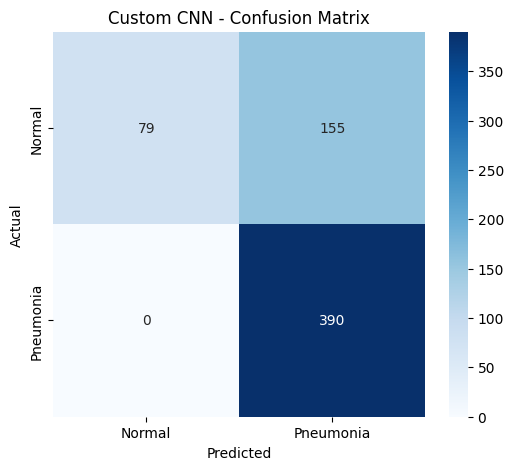

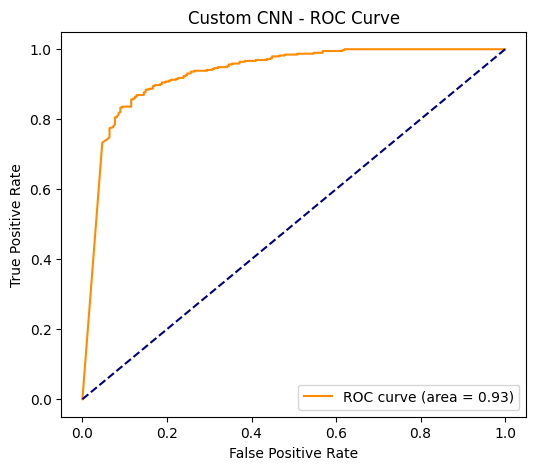

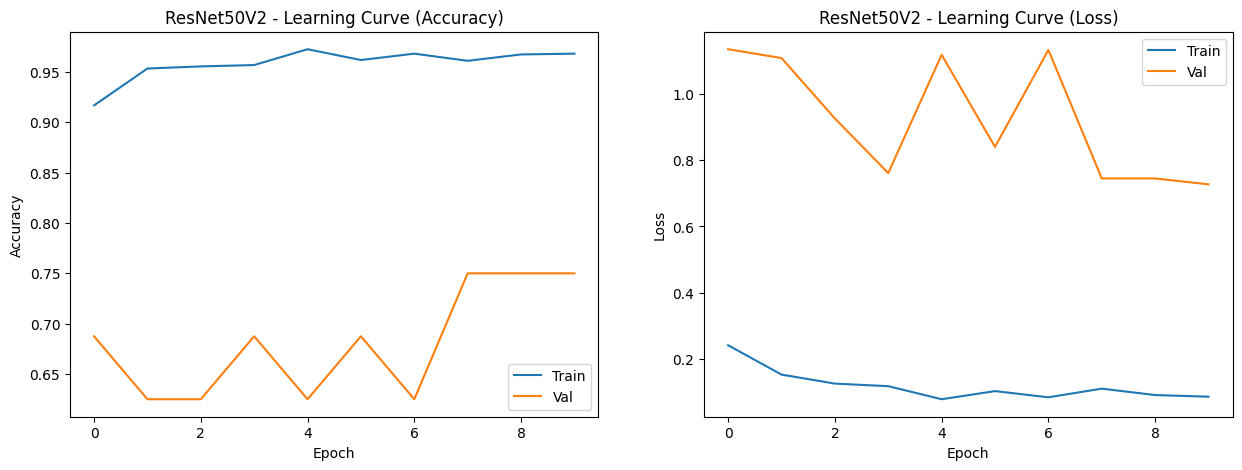

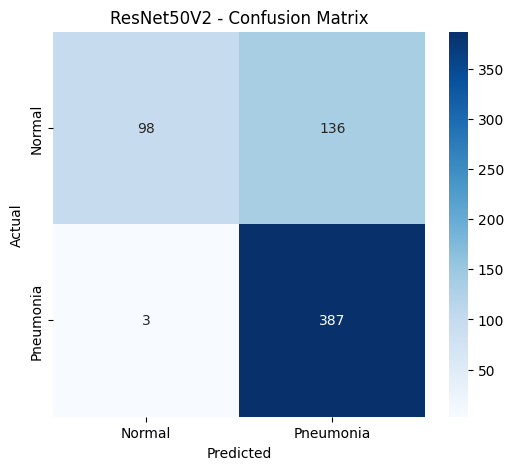

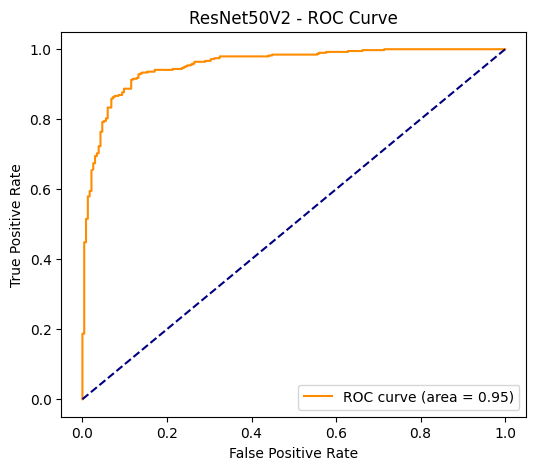

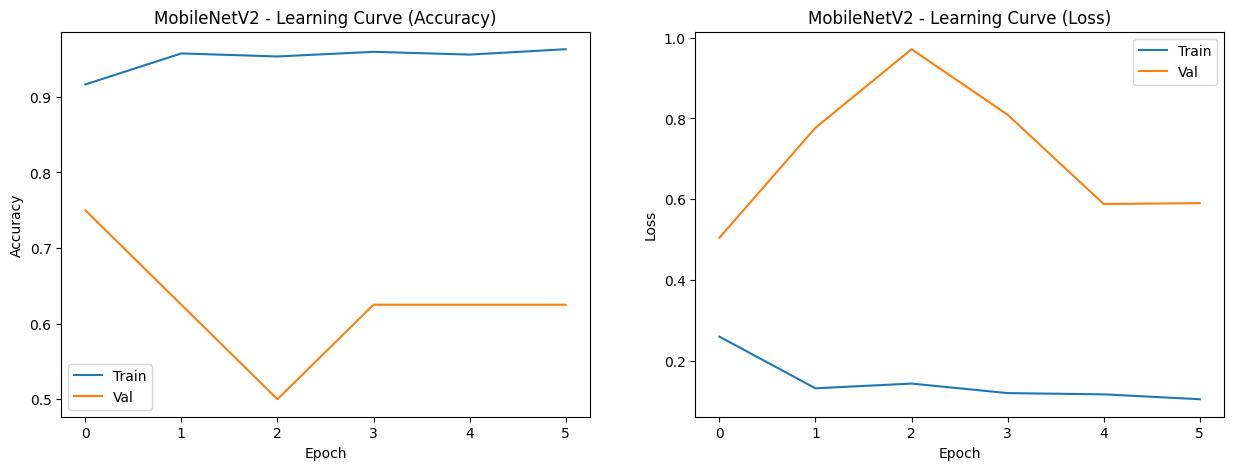

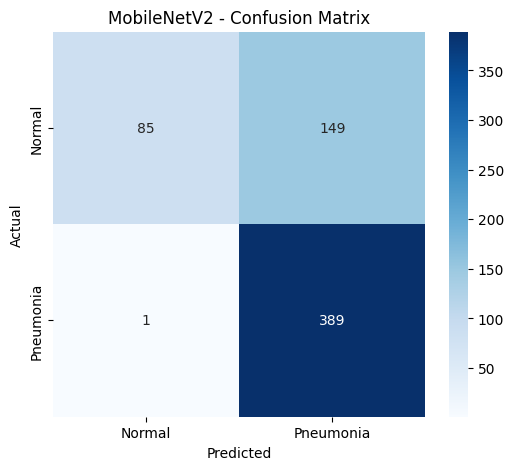

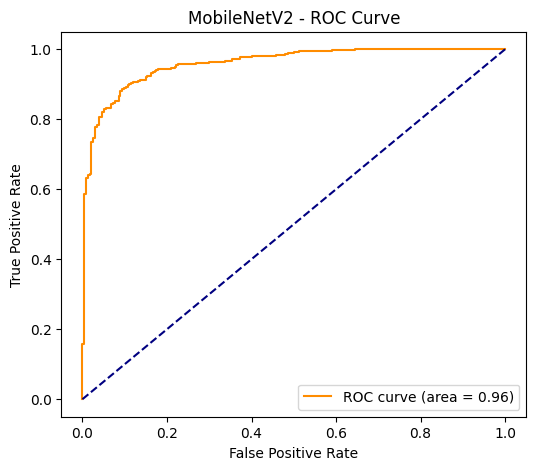

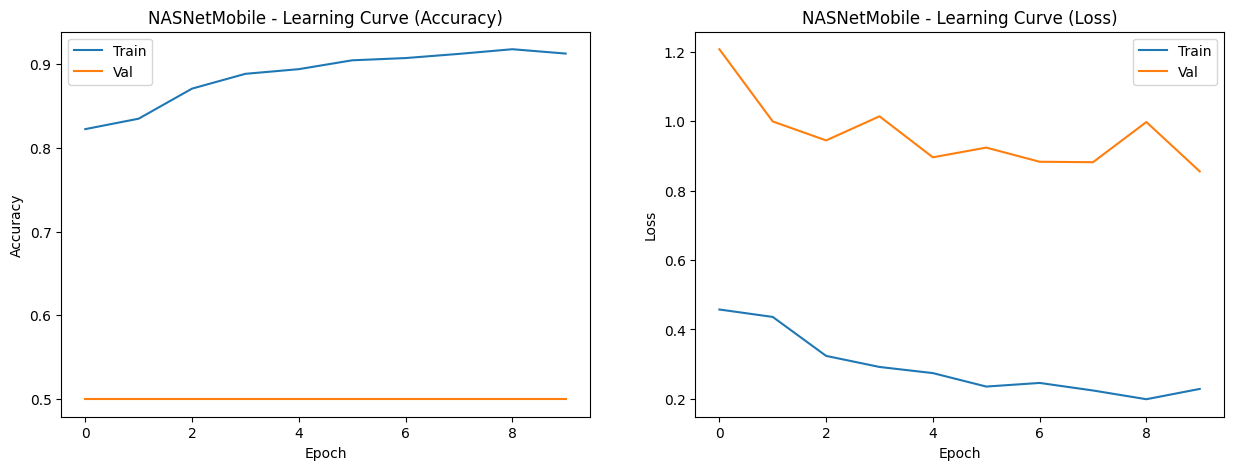

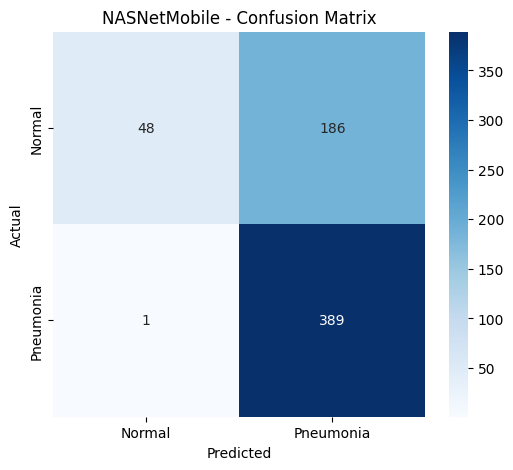

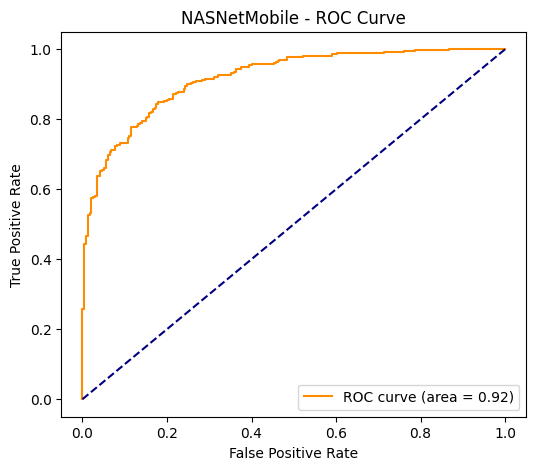

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

def plot_dl_diagnostics(history, model, name, test_ds):
    # 1. Learning Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Val')
    ax1.set_title(f'{name} - Learning Curve (Accuracy)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Val')
    ax2.set_title(f'{name} - Learning Curve (Loss)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    plt.show()

    # 2. Evaluation on Test Set
    y_true = []
    y_probs = []
    for imgs, lbls in test_ds:
        y_true.extend(lbls.numpy())
        y_probs.extend(model.predict(imgs, verbose=0).ravel())

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    y_pred = (y_probs > 0.5).astype(int)

    # 3. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    # 4. ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.title(f'{name} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.show()

# Visualize diagnostics for each experiment
print("📊 Generating Visual Diagnostics for Deep Learning Models...")
diagnostics = [
    (history_custom, custom_cnn, 'Custom CNN'),
    (history_resnet, resnet_model, 'ResNet50V2'),
    (history_mobile, mobilenet_model, 'MobileNetV2'),
    (history_nasnet, nasnet_model, 'NASNetMobile')
]

for hist, model, label in diagnostics:
    plot_dl_diagnostics(hist, model, label, test_dataset)